- usar o Python 3.12.1

In [1]:
import tensorflow as tf
print("TensorFlow instalado e funcionando! Versão:", tf.__version__)

TensorFlow instalado e funcionando! Versão: 2.21.0


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
import json
import shutil
import warnings
import tensorflow as tf

In [3]:
#import plotly
#import plotly.express as px
#import plotly.graph_objects as go
#from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from matplotlib.ticker import MaxNLocator

In [4]:

from scipy.stats import kurtosis, skew, iqr
from scipy.signal import detrend, windows



warnings.filterwarnings("ignore")

import importlib.metadata as metadata

#import kaleido

# print("Plotly:", plotly.__version__)
print("nbformat:", metadata.version("nbformat"))
#print("Kaleido:", metadata.version("kaleido"))

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# Aponta para a pasta 'dataset' localizada na raiz do seu projeto local
pasta_dataset = './dataset' 

for dirname, _, filenames in os.walk(pasta_dataset):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

nbformat: 5.11.1


In [6]:
# ------------------------------------------------------------
# 1. CONFIGURAÇÃO
# ------------------------------------------------------------

# df_bruto = pd.read_csv(
    # "/kaggle/input/datasets/chcarneiro/150rpm-aj-17115-base/150rpm_aj_17115_Base.csv"
# )

#("D:\Projeto Acelerômetro\1 - Pesquisas e Relatórios\Dataset\coletas_21_08_noite\03_150rpm_1m_18380_2026-08-21_21-51-28.csv")

df_bruto = pd.read_csv(
    r"D:/projeto_acelerometro/1_pesquisas_relatorios/Dataset/coletas_21_08_noite/03_150rpm_1m_18380_2026-08-21_21-51-28.csv"
)
print(df_bruto)

           t_us    x_mg    y_mg      z_mg
0             0  68.869  35.380   971.852
1           596  32.940  23.424  1044.625
2          1206  31.049  17.934  1022.970
3          1754  26.840 -18.849  1032.425
4          2363  49.776  33.977  1021.994
...         ...     ...     ...       ...
21285  12677899  75.884  22.082   992.714
21286  12678505  69.357  14.701   997.655
21287  12679090  25.010  39.955   997.655
21288  12679665  74.969  36.722  1027.972
21289  12680266  36.234  10.126  1000.827

[21290 rows x 4 columns]


In [7]:
DESCARTE_INICIAL = 2_000
TAMANHO_BLOCO = 250          # Amostras por bloco para gráfico de barras
JANELA_MEDIA_MOVEL = 250     # Amostras
FATOR_IQR = 1.5              # Critério de Tukey
SALVAR_PNG = True

COLUNA_TEMPO = "t_us"
EIXOS = ["x_mg", "y_mg", "z_mg"]


In [8]:
# -----------------------------------------------------------------------------
# 2. ESTRUTURA DE DIRETÓRIOS LOCAIS (VS CODE)
# -----------------------------------------------------------------------------
# Define a pasta raiz do projeto local
from pathlib import Path

PASTA_SAIDA = Path("./resultados/150rpm_aj_17115_Base")

# Mapeia as subpastas operacionais criadas
PASTA_GRAFICOS = PASTA_SAIDA / "graficos"
PASTA_TABELAS = PASTA_SAIDA / "tabelas"
PASTA_DATA_CARD = PASTA_SAIDA / "data_card_snapshot"

# Cria a árvore completa de diretórios com verificação de segurança
for pasta in [PASTA_SAIDA, PASTA_GRAFICOS, PASTA_TABELAS, PASTA_DATA_CARD]:
    pasta.mkdir(parents=True, exist_ok=True)

print(f"Estrutura de pastas gerada com sucesso em:\n -> {PASTA_SAIDA.resolve()}")



Estrutura de pastas gerada com sucesso em:
 -> D:\projeto_acelerometro\1_Pesquisas_relatorios\Dataset\analise_FFT\codes\resultados\150rpm_aj_17115_Base


In [9]:
np.random.seed(42)
tf.random.set_seed(42)

print(f"Diretório de saída: {PASTA_SAIDA}")


Diretório de saída: resultados\150rpm_aj_17115_Base


- Tratando um erro de leitura de função None: se nenhum diretório for passado na chamada, ela assume automaticamente a pasta atual do projeto (Path.cwd()).

In [10]:
# ------------------------------------------------------------
# 2. LOCALIZAÇÃO E LEITURA DO CSV
# ------------------------------------------------------------

from typing import Optional

def localizar_csv_local(ARQUIVO_ESPERADO: str, diretorio_base: Optional[Path] = None) -> Path:
    """
    Localiza o arquivo CSV no ambiente local.
    Realiza uma busca recursiva a partir da pasta informada ou do diretório do projeto.
    """
    # Trata o diretorio_base quando é None ou não foi passado
    if diretorio_base is None:
        diretorio_base = Path.cwd()

    # Busca pelo arquivo esperado
    candidatos = list(diretorio_base.rglob(ARQUIVO_ESPERADO))

    # Se não encontrar o arquivo esperado, procura qualquer CSV na pasta
    if not candidatos:
        candidatos = list(diretorio_base.rglob("*.csv"))

    # Tratando a ausência do arquivo no diretório de entrada
    if not candidatos:
        raise FileNotFoundError(
            f"Nenhum arquivo CSV foi localizado em '{diretorio_base.resolve()}'. "
            "Confirme se os dados brutos de entrada estão disponíveis no diretório."
        )

    # Se encontrar múltiplos arquivos, utiliza o primeiro e emite aviso
    if len(candidatos) > 1:
        print("⚠️ Mais de um CSV encontrado. Será utilizado o seguinte arquivo:")
        print(f" -> {candidatos[0].resolve()}")

    return candidatos[0]

In [12]:
# CAMINHO_CSV = localizar_csv_kaggle("150rpm_aj_17115_Base.csv")
# CAMINHO_CSV = localizar_csv_kaggle("150rpm_aj_17115_Base.csv")
# print(f"\nArquivo selecionado: {CAMINHO_CSV}")

NOME_ARQUIVO = "03_150rpm_1m_18380_2026-08-21_21-51-28.csv"

# Pasta onde os dados brutos de entrada estão armazenados
pasta_dataset = Path(r"D:\projeto_acelerometro\1_Pesquisas_relatorios\Dataset\coletas_21_08_noite")

# Busca o arquivo CSV no diretório informado
CAMINHO_CSV = localizar_csv_local(NOME_ARQUIVO, pasta_dataset)
print(f"\n✅ Arquivo selecionado: {CAMINHO_CSV.resolve()}")

# Carrega o CSV em um DataFrame do Pandas
df_bruto = pd.read_csv(CAMINHO_CSV)

# Padronização dos nomes de colunas
df_bruto.columns = (
    df_bruto.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.lower()
)

mapa_colunas = {
    "t_us": "t_us",
    "x_mg": "x_mg",
    "y_mg": "y_mg",
    "z_mg": "z_mg"
}




✅ Arquivo selecionado: D:\projeto_acelerometro\1_Pesquisas_relatorios\Dataset\coletas_21_08_noite\03_150rpm_1m_18380_2026-08-21_21-51-28.csv


In [13]:
colunas_necessarias = list(mapa_colunas.values())
colunas_ausentes = [c for c in colunas_necessarias if c not in df_bruto.columns]

"""if colunas_ausentes:
    raise ValueError(
        f"Colunas obrigatórias não encontradas: {colunas_ausentes}\n"
        f"Colunas disponíveis: {df_bruto.columns.tolist()}"
    )"""

df_bruto = df_bruto[[COLUNA_TEMPO] + EIXOS].copy()

for coluna in [COLUNA_TEMPO] + EIXOS:
    df_bruto[coluna] = pd.to_numeric(df_bruto[coluna], errors="coerce")
#coerce: substitui esse valor por NaN, em vez de parar a execução com erro.

print(f"Linhas brutas: {len(df_bruto):,}")
print(f"Colunas: {df_bruto.columns.tolist()}")

Linhas brutas: 21,290
Colunas: ['t_us', 'x_mg', 'y_mg', 'z_mg']


In [14]:
# ------------------------------------------------------------
# 4. DESCARTE DAS 2.000 AMOSTRAS INICIAIS
# ------------------------------------------------------------

if len(df_bruto) <= DESCARTE_INICIAL:
    raise ValueError(
        f"O arquivo possui {len(df_bruto)} linhas, menor ou igual ao "
        f"descarte configurado de {DESCARTE_INICIAL} linhas."
    )

df = df_bruto.iloc[DESCARTE_INICIAL:].copy().reset_index(drop=True)

# Tempo relativo em segundos a partir da primeira amostra válida
df["tempo_s"] = (
    (df[COLUNA_TEMPO] - df[COLUNA_TEMPO].iloc[0]) / 1_000_000.0
)

# Número temporal/índice de coleta após descarte
df.insert(0, "numero_temporal", np.arange(1, len(df) + 1))

print(f"\nLinhas após descarte das {DESCARTE_INICIAL:,} iniciais: {len(df):,}")
print(f"Duração final estimada: {df['tempo_s'].iloc[-1]:.3f} s")



Linhas após descarte das 2,000 iniciais: 19,290
Duração final estimada: 11.489 s


- antes de rodar instale, via terminal: pip install nbformat

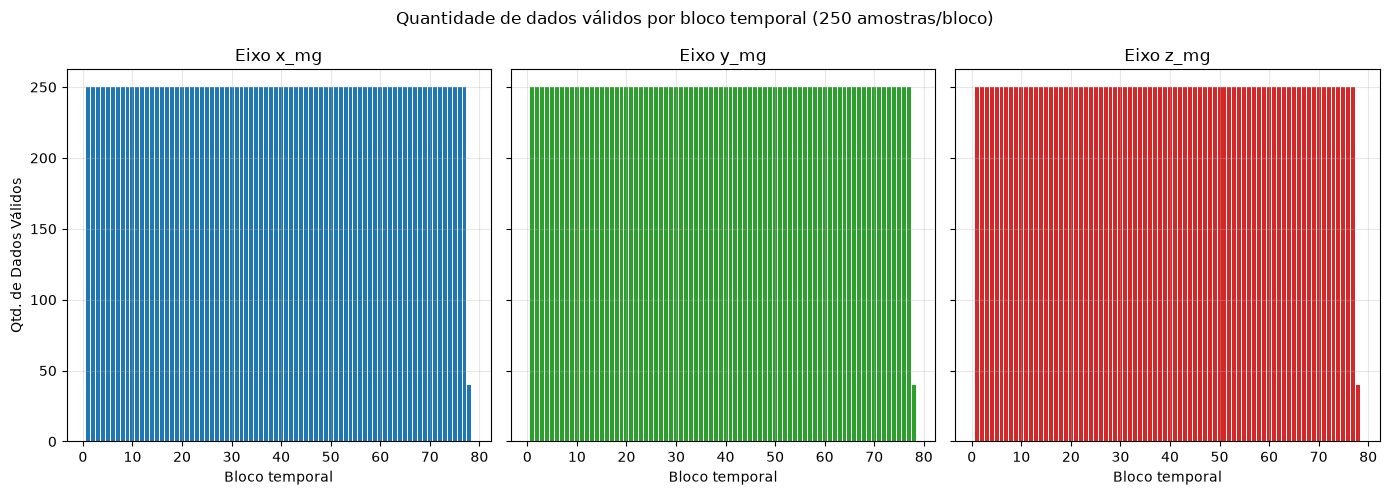

In [15]:
# import plotly.express as px
# from plotly.subplots import make_subplots
# import plotly.graph_objects as go

# ------------------------------------------------------------
# 5. GRÁFICOS DE BARRAS LADO A LADO (SUBPLOTS)
# ------------------------------------------------------------

df["bloco_temporal"] = (df["numero_temporal"] - 1) // TAMANHO_BLOCO + 1

contagem_por_bloco = (
    df.groupby("bloco_temporal")[EIXOS]
    .count()
    .reset_index()
)

# Mapeamento de cores padronizado para os eixos cinemáticos
cores_eixos = {
    "x_mg": "#1f77b4",
    "y_mg": "#2ca02c",
    "z_mg": "#d62728"
}

# 1. Cria uma figura com 1 linha e 3 colunas compartilhando o eixo Y
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(14, 5),
    sharey=True    # Reduz o espaço entre os gráficos
)

# 2. Adiciona as barras de cada eixo em sua respectiva coluna
for idx, eixo in enumerate(EIXOS):
    axes[idx].bar(
        contagem_por_bloco["bloco_temporal"],
        contagem_por_bloco[eixo],
        color=cores_eixos.get(eixo, "#1f77b4")
    )
    axes[idx].set_title(f"Eixo {eixo}")
    axes[idx].set_xlabel("Bloco temporal")
    axes[idx].grid(True, alpha=0.30)

axes[0].set_ylabel("Qtd. de Dados Válidos")
fig.suptitle(
    f"Quantidade de dados válidos por bloco temporal "
    f"({TAMANHO_BLOCO} amostras/bloco)"
)
fig.tight_layout()
plt.show()

Na plotagem temos:

- No Eixo X (Horizontal): São barras numeradas de 1 a 77 (cada barra representa um bloco individual de tempo
calculados como 19.290 linhas / 250 amostras por bloco).

- No Eixo Y (Vertical): A altura de cada uma dessas 77 barras vai até a linha do 250.

In [16]:
# ------------------------------------------------------------
# 6. TABELA DE QUALIDADE ESTATÍSTICA
# ------------------------------------------------------------

from scipy.stats import kurtosis, skew, iqr

def calcular_metricas_qualidade(df_entrada: pd.DataFrame,
                                eixos: list,
                                janela_mm: int = 250) -> pd.DataFrame:
    totais = len(df_entrada)

    registros = []
    
    for eixo in eixos:
        s = df_entrada[eixo].dropna()
        n_validos = len(s)
        n_ausentes = totais - n_validos
        
        # Estatísticas descritivas básicas
        std = s.std(ddof=1)
        mean = s.mean()
        s_min, s_max = s.min(), s.max()
        
        registros.append({
            "eixo": eixo,
            "amostras_totais": totais,
            "valores_validos": n_validos,
            "valores_ausentes": n_ausentes,
            "percentual_ausente": (n_ausentes / totais) * 100,
            "media_mg": mean,
            "mediana_mg": s.median(),
            "rms_mg": np.sqrt(np.mean(s**2)),
            "desvio_padrao_mg": std,
            "variancia_mg2": s.var(ddof=1),
            "minimo_mg": s_min,
            "maximo_mg": s_max,
            "amplitude_pico_a_pico_mg": s_max - s_min,
            "assimetria_skewness": skew(s, bias=False),
            "curtose_excesso": kurtosis(s, fisher=True, bias=False),
            "iqr_mg": iqr(s),
            "coeficiente_variacao_percentual": (std / np.abs(mean) * 100) if mean != 0 else np.nan
        })

    # Cria o DataFrame original e realiza a transposição
    df_metricas = pd.DataFrame(registros).set_index("eixo").T
    
    # Reseta o índice para que os nomes das métricas fiquem em uma coluna chamada "metrica"
    df_metricas = df_metricas.reset_index().rename(columns={"index": "metrica"})

    return df_metricas


tabela_qualidade = calcular_metricas_qualidade(
    df,
    EIXOS,
    JANELA_MEDIA_MOVEL
)

tabela_qualidade.to_csv(
    PASTA_TABELAS / "01_metricas_qualidade_apos_descarte.csv",
    index=False,
    encoding="utf-8-sig"
)

display(tabela_qualidade.round(5))


eixo,metrica,x_mg,y_mg,z_mg
0,amostras_totais,19290.00000,19290.00000,19290.00000
1,valores_validos,19290.00000,19290.00000,19290.00000
2,valores_ausentes,0.00000,0.00000,0.00000
3,percentual_ausente,0.00000,0.00000,0.00000
4,media_mg,49.16455,20.30113,1012.24154
5,mediana_mg,48.80000,19.76400,1012.53900
6,rms_mg,60.22478,44.14966,1015.08873
7,desvio_padrao_mg,34.78410,39.20633,75.97699
8,variancia_mg2,1209.93393,1537.13660,5772.50271
9,minimo_mg,-359.16800,-319.76200,-253.33300


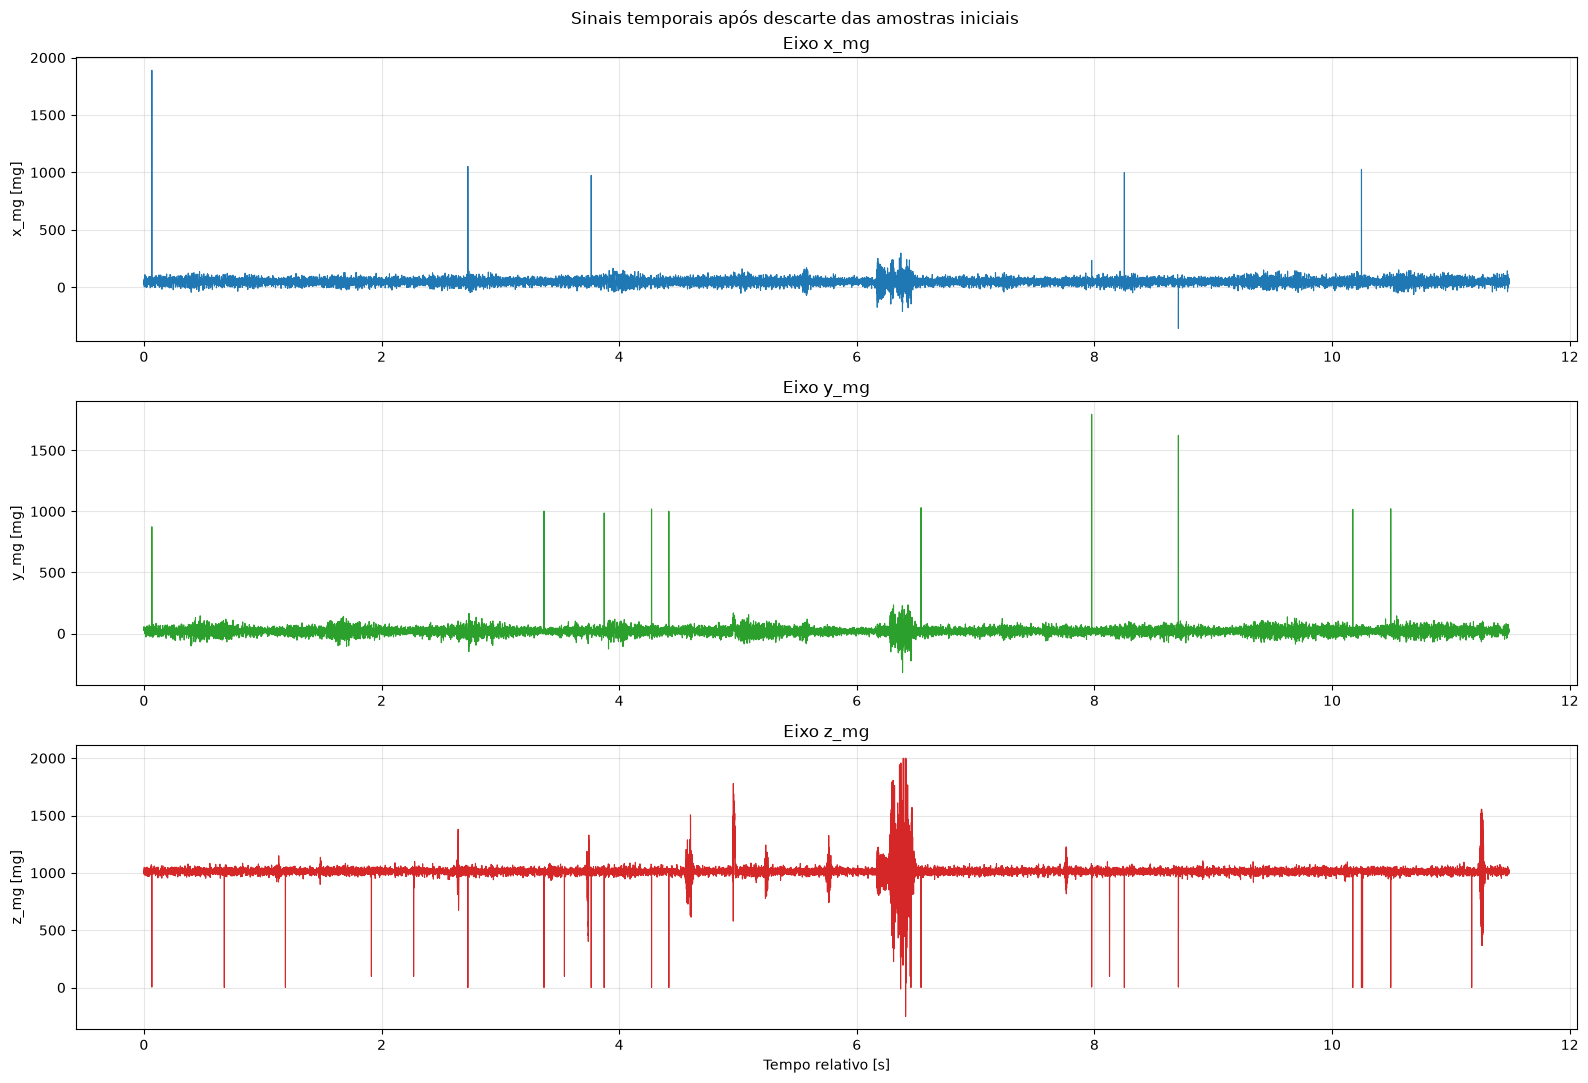

In [18]:
# ------------------------------------------------------------
# 8. PLOTAGEM TEMPORAL DOS TRÊS EIXOS
# ------------------------------------------------------------

fig_sinais, axes_sinais = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 11),
    sharex=False
)

cores = {
    "x_mg": "#1f77b4",
    "y_mg": "#2ca02c",
    "z_mg": "#d62728"
}

for linha, eixo in enumerate(EIXOS):
    axes_sinais[linha].plot(
        df["tempo_s"],
        df[eixo],
        color=cores[eixo],
        linewidth=0.8
    )
    axes_sinais[linha].set_title(f"Eixo {eixo}")
    axes_sinais[linha].set_ylabel(f"{eixo} [mg]")
    axes_sinais[linha].grid(True, alpha=0.30)

axes_sinais[-1].set_xlabel("Tempo relativo [s]")
fig_sinais.suptitle("Sinais temporais após descarte das amostras iniciais")
fig_sinais.tight_layout()
plt.show()


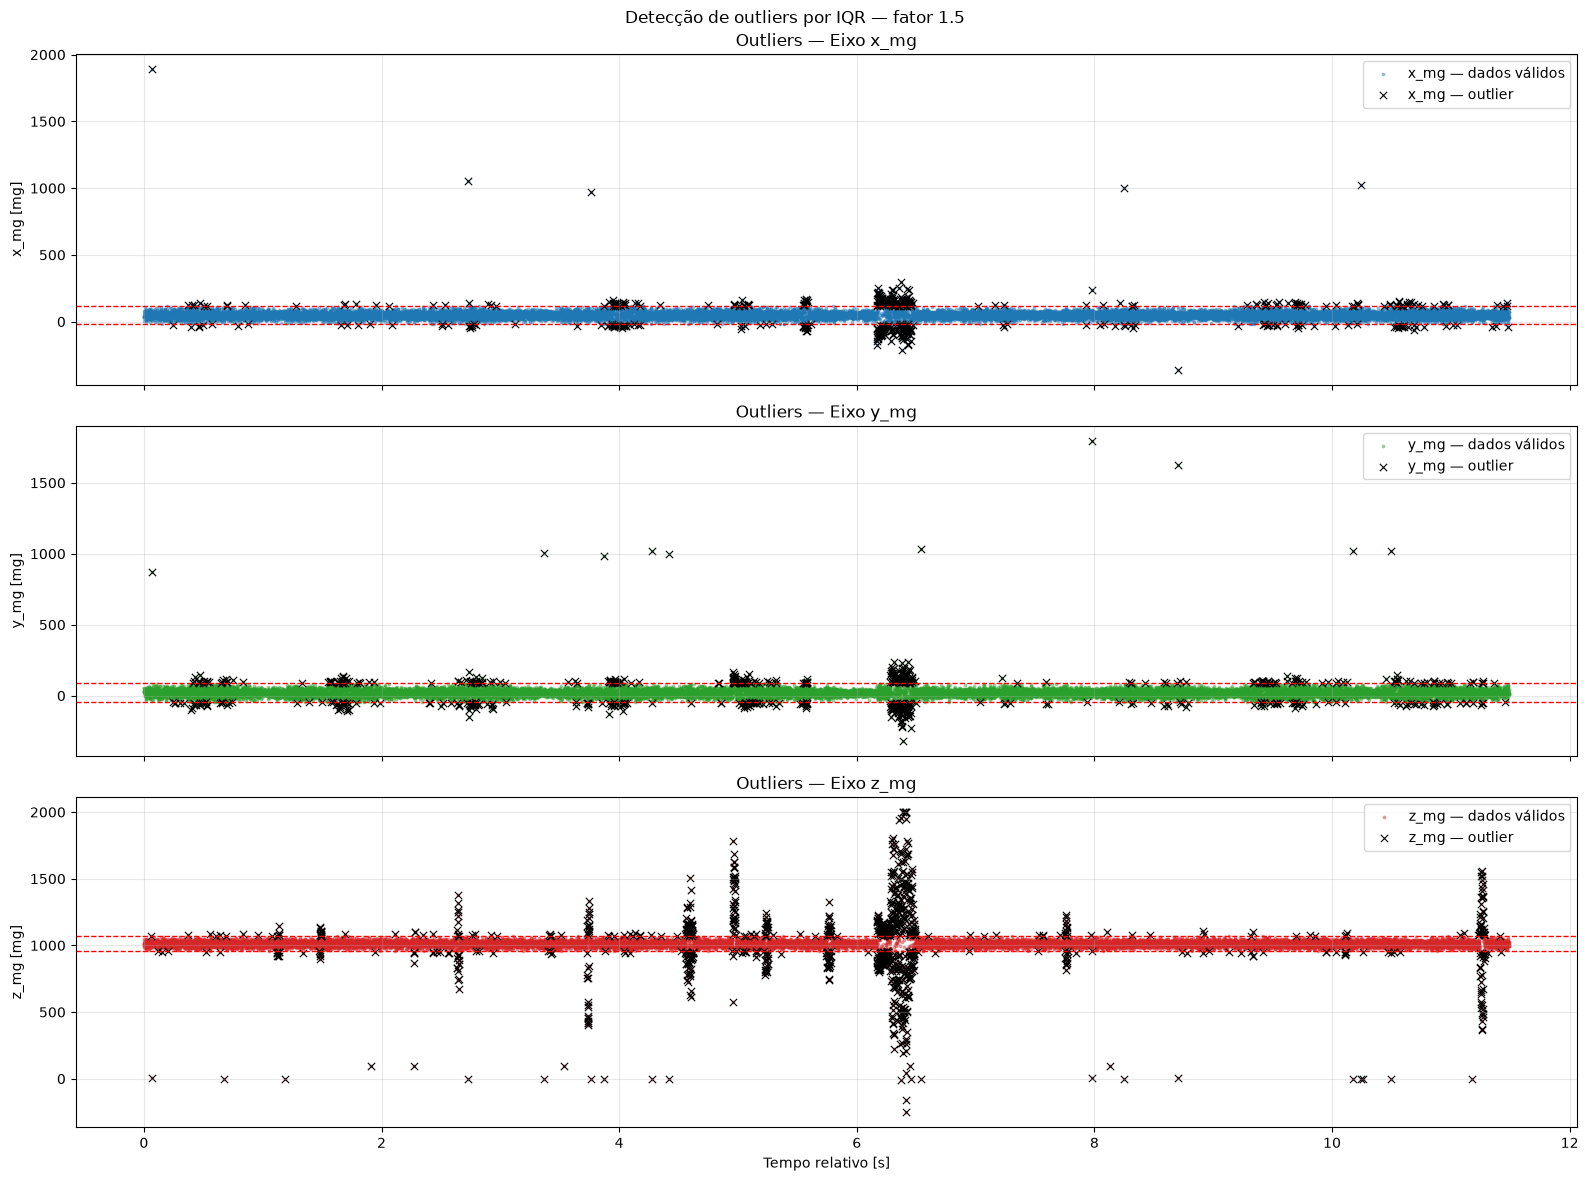

In [19]:
# ------------------------------------------------------------
# 9. DETECÇÃO E PLOTAGEM DE OUTLIERS POR EIXO
# ------------------------------------------------------------

limites_outliers = {}
mascaras_outliers = pd.DataFrame(index=df.index)

for eixo in EIXOS:
    q1 = df[eixo].quantile(0.25)
    q3 = df[eixo].quantile(0.75)
    intervalo_iqr = q3 - q1

    limite_inferior = q1 - FATOR_IQR * intervalo_iqr
    limite_superior = q3 + FATOR_IQR * intervalo_iqr

    mascara_inferior = df[eixo] < limite_inferior
    mascara_superior = df[eixo] > limite_superior
    mascara_outlier = mascara_inferior | mascara_superior

    mascaras_outliers[f"{eixo}_abaixo"] = mascara_inferior
    mascaras_outliers[f"{eixo}_acima"] = mascara_superior
    mascaras_outliers[f"{eixo}_outlier"] = mascara_outlier

    limites_outliers[eixo] = {
        "q1": q1,
        "q3": q3,
        "iqr": intervalo_iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior
    }

fig_outliers, axes_outliers = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 12),
    sharex=True
)

for linha, eixo in enumerate(EIXOS):
    mascara = mascaras_outliers[f"{eixo}_outlier"]
    ax = axes_outliers[linha]

    ax.scatter(
        df["tempo_s"],
        df[eixo],
        s=3,
        color=cores[eixo],
        alpha=0.38,
        label=f"{eixo} — dados válidos"
    )

    ax.scatter(
        df.loc[mascara, "tempo_s"],
        df.loc[mascara, eixo],
        s=28,
        color="#000000",
        marker="x",
        linewidths=0.8,
        label=f"{eixo} — outlier"
    )

    ax.axhline(
        limites_outliers[eixo]["limite_inferior"],
        linestyle="--",
        color="#ff0000",
        linewidth=1.0
    )
    ax.axhline(
        limites_outliers[eixo]["limite_superior"],
        linestyle="--",
        color="#ff0000",
        linewidth=1.0
    )

    ax.set_title(f"Outliers — Eixo {eixo}")
    ax.set_ylabel(f"{eixo} [mg]")
    ax.grid(True, alpha=0.30)
    ax.legend(loc="best")

axes_outliers[-1].set_xlabel("Tempo relativo [s]")
fig_outliers.suptitle(f"Detecção de outliers por IQR — fator {FATOR_IQR}")
fig_outliers.tight_layout()
plt.show()



Delta t mediano [us]: 596.0
Delta t médio [us]: 595.6489190730468
Delta t mínimo [us]: 475.0
Delta t máximo [us]: 1412.0
Desvio-padrão de delta t [us]: 79.67934548126256
Frequência estimada [Hz]: 1677.8523489932886


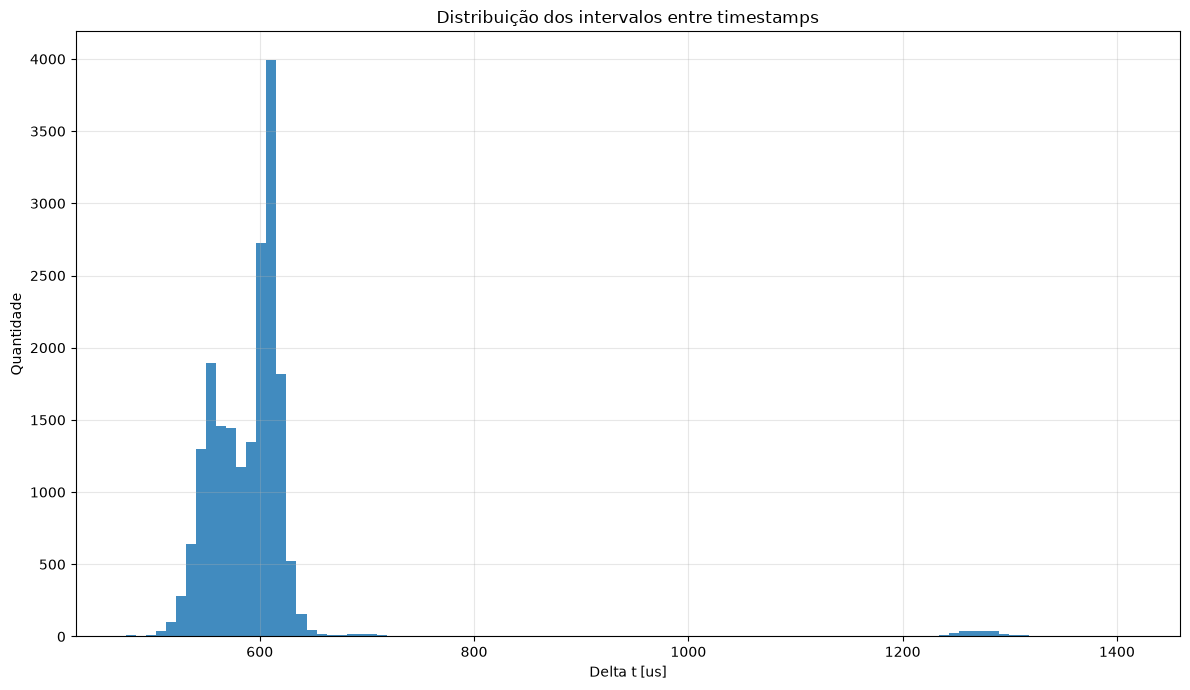

In [21]:
# Regularidade temporal:
dt_us = np.diff(df["t_us"].to_numpy(dtype=float))

FS_ESTIMADA = 1_000_000 / np.median(dt_us)

print("Delta t mediano [us]:", np.median(dt_us))
print("Delta t médio [us]:", np.mean(dt_us))
print("Delta t mínimo [us]:", np.min(dt_us))
print("Delta t máximo [us]:", np.max(dt_us))
print("Desvio-padrão de delta t [us]:", np.std(dt_us))
print("Frequência estimada [Hz]:", FS_ESTIMADA)

fig_dt, ax_dt = plt.subplots(figsize=(12, 7))
ax_dt.hist(dt_us, bins=100, color="#1f77b4", alpha=0.85)
ax_dt.set_title("Distribuição dos intervalos entre timestamps")
ax_dt.set_xlabel("Delta t [us]")
ax_dt.set_ylabel("Quantidade")
ax_dt.grid(True, alpha=0.30)
fig_dt.tight_layout()
plt.show()

Olhando a tabela gerada, vemos que mediana e média são quase iguais e indicam amostragem centrada em 600 uS. O desvio padrão de 81 uS é muito alto, correspondendo a 13,5% (80,95/600). O período da mediana está em:

freq. amostragem: 1/ (600x 10-6) = 1666,6 Hz (ou 600us)

O IIS3 amostra com uma taxa de 26666,67 Hz (Tiis3 = 37,5 us)....

Entendo que estamos tendo uma amostragem que fica em 1/16 da capacidade do IIS3. Como estamos amostrando com 600uS, um ciclo de leitura captura um valor e descarta 16 valores.

A FFT está sendo amostrada em 1.666Hz. Sem o Aliasing: 8333,33 Hz (faixa compreensiva de validação da FFT), muito abaixo dos 26.667 Hz.


A coleta apresenta um jitter nos  instantes de leitura/registro no CSV, provavelmente por que termos a temporização controlada apenas no software. Um caminho seria usar temporizadores de HW e controlar a quisição da transmissão do streaming de dados Esse jitter está "ferrando" a geraçaõ do espectro. Estamos trabalhnado com comunicação SPI, o que dá uma excelente taxa de transmissão, mesmo assim não garante uniformidade temporal de aquisição. Assim, a aquisição não está muito uniforme. Tem uma taxa central em torno de 1.666 KHz e um espraiamento até 760 Hz. Entretanto, a dispersão dos intervalos mostra que as amostras armazenadas no CSV não são perfeitamente equiespaçadas. O cálculo da FFT pressupõe amostras com espaçamentos iguais. Esse histograma parece indicar uma limitação ou característica da temporização da aquisição:

Tamostra = Tsensor + Tprocess. + Ttransmissão (SPI e USB) + Tespera.

Como alguns desses termos variam, o intervalo total também varia.
Verifique que temos tempos até 1300uS.

temos que verificar como criar um buffer no microcontrolador para ateunar esse problema. Refazer as leituras nessa velocidade p.e. e verificar o resultado.




Frequência de amostragem estimada: 1677.852 Hz
Frequência de Nyquist: 838.926 Hz


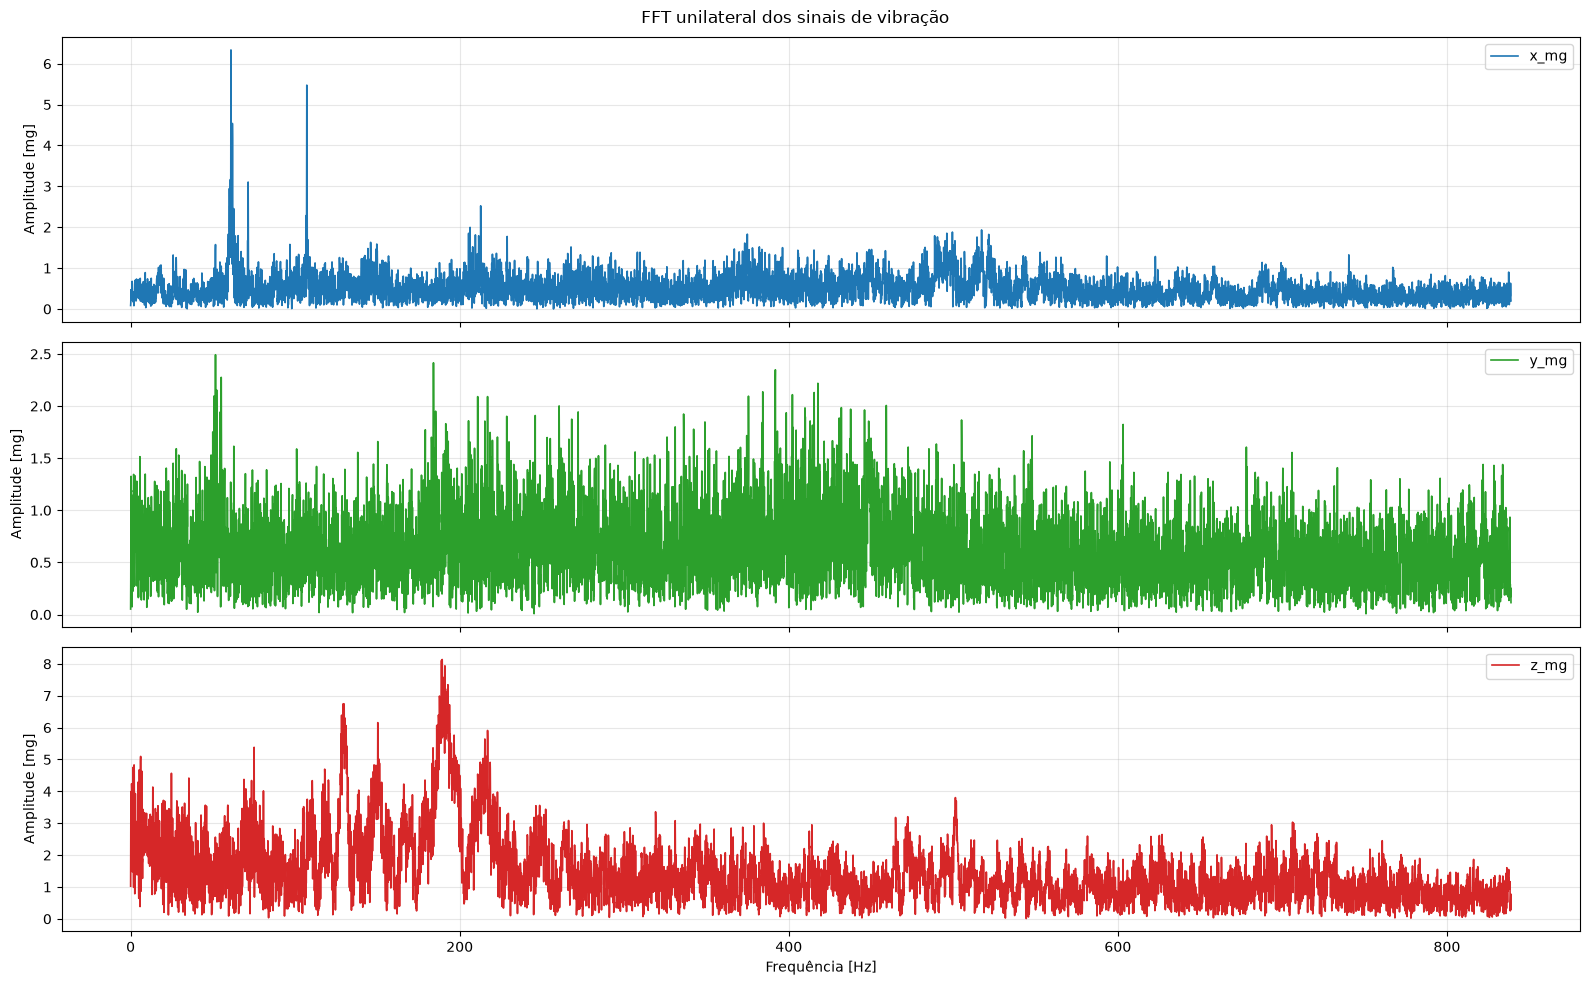

In [22]:
# ------------------------------------------------------------
# 10. FFT DOS SINAIS X, Y E Z
# ------------------------------------------------------------

def estimar_frequencia_amostragem(tempo_us: pd.Series) -> float:
    """
    Estima Fs por meio da mediana dos incrementos temporais positivos.
    """
    delta_t_us = np.diff(tempo_us.to_numpy(dtype=float))
    delta_t_us = delta_t_us[delta_t_us > 0]

    if len(delta_t_us) == 0:
        raise ValueError(
            "Não foi possível estimar a frequência de amostragem: "
            "timestamps sem incremento positivo."
        )

    periodo_s = np.median(delta_t_us) / 1_000_000.0
    return 1.0 / periodo_s


def calcular_fft_unilateral(sinal: pd.Series, fs: float):
    """
    Remove tendência linear, aplica janela Hann e calcula FFT unilateral.
    """
    vetor = sinal.interpolate(limit_direction="both").to_numpy(dtype=np.float64)
    n = len(vetor)

    vetor_sem_tendencia = detrend(vetor, type="linear")
    janela = windows.hann(n, sym=False)
    ganho_coerente = janela.mean()

    espectro = np.fft.rfft(vetor_sem_tendencia * janela)
    frequencias = np.fft.rfftfreq(n, d=1.0 / fs)

    amplitude = np.abs(espectro) / (n * ganho_coerente)

    if n % 2 == 0:
        amplitude[1:-1] *= 2.0
    else:
        amplitude[1:] *= 2.0

    return frequencias, amplitude


FS_ESTIMADA = estimar_frequencia_amostragem(df[COLUNA_TEMPO])
NYQUIST = FS_ESTIMADA / 2.0

print(f"\nFrequência de amostragem estimada: {FS_ESTIMADA:.3f} Hz")
print(f"Frequência de Nyquist: {NYQUIST:.3f} Hz")

fig_fft, axes_fft = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for linha, eixo in enumerate(EIXOS):
    frequencias, amplitude = calcular_fft_unilateral(df[eixo], FS_ESTIMADA)

    axes_fft[linha].plot(
        frequencias,
        amplitude,
        color=cores[eixo],
        linewidth=1.2,
        label=eixo
    )
    axes_fft[linha].set_ylabel("Amplitude [mg]")
    axes_fft[linha].grid(True, alpha=0.30)
    axes_fft[linha].legend(loc="best")

axes_fft[-1].set_xlabel("Frequência [Hz]")
fig_fft.suptitle("FFT unilateral dos sinais de vibração")
fig_fft.tight_layout()
plt.show()


In [23]:
# ------------------------------------------------------------
# 11. RECONSTRUÇÃO, REMOÇÃO DE OUTLIERS E NORMALIZAÇÃO Z-SCORE
# ------------------------------------------------------------

# Linha é removida se houver outlier em pelo menos um dos três eixos
mascara_outlier_global = mascaras_outliers[
    [f"{eixo}_outlier" for eixo in EIXOS]
].any(axis=1)

df_sem_outliers = df.loc[~mascara_outlier_global].copy().reset_index(drop=True)

# Z-score calculado após remoção de outliers.
# ddof=0 corresponde ao desvio padrão populacional.
medias_limpo = df_sem_outliers[EIXOS].mean()
desvios_limpo = df_sem_outliers[EIXOS].std(ddof=0)

if (desvios_limpo == 0).any():
    raise ValueError(
        "Pelo menos um eixo tem desvio padrão nulo após a remoção de outliers; "
        "não é possível realizar a normalização Z-score."
    )

df_off_machine_1_N = pd.DataFrame()

# Preserva rastreabilidade para o dado original
df_off_machine_1_N["numero_temporal"] = df_sem_outliers["numero_temporal"]
df_off_machine_1_N["t_us"] = df_sem_outliers[COLUNA_TEMPO]
df_off_machine_1_N["tempo_s"] = df_sem_outliers["tempo_s"]

# Dados normalizados, mantendo nomes explícitos
for eixo in EIXOS:
    nome_normalizado = eixo.replace("_mg", "_zscore")
    df_off_machine_1_N[nome_normalizado] = (
        (df_sem_outliers[eixo] - medias_limpo[eixo]) / desvios_limpo[eixo]
    )

# TensorFlow: dataset pronto para pipeline de ML.
# Mantém apenas as variáveis de entrada normalizadas.
tensor_off_machine_1_N = tf.convert_to_tensor(
    df_off_machine_1_N[
        ["x_zscore", "y_zscore", "z_zscore"]
    ].to_numpy(dtype=np.float32),
    dtype=tf.float32
)

dataset_tf_off_machine_1_N = (
    tf.data.Dataset
    .from_tensor_slices(tensor_off_machine_1_N)
    .cache()
    .batch(256)
    .prefetch(tf.data.AUTOTUNE)
)

df_off_machine_1_N.to_csv(
    PASTA_SAIDA / "off_machine_1_N.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nDataset normalizado criado:")
print(f"Nome: off_machine_1_N")
print(f"Linhas: {len(df_off_machine_1_N):,}")
print(f"Shape do tensor TensorFlow: {tensor_off_machine_1_N.shape}")
print(f"Element spec tf.data: {dataset_tf_off_machine_1_N.element_spec}")


Dataset normalizado criado:
Nome: off_machine_1_N
Linhas: 17,673
Shape do tensor TensorFlow: (17673, 3)
Element spec tf.data: TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)


In [24]:
import json
import shutil
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. TABELA DE EXCLUSÕES POR EIXO (TRANSPOSTA)
# ------------------------------------------------------------
DATASET_SLUG = "chcarneiro/150rpm-aj-17115-base"

tabela_exclusoes_raw = []

for eixo in EIXOS:
    abaixo = int(mascaras_outliers[f"{eixo}_abaixo"].sum())
    acima = int(mascaras_outliers[f"{eixo}_acima"].sum())
    total = int(mascaras_outliers[f"{eixo}_outlier"].sum())

    tabela_exclusoes_raw.append({
        "eixo": eixo,
        "limite_inferior_iqr_mg": limites_outliers[eixo]["limite_inferior"],
        "limite_superior_iqr_mg": limites_outliers[eixo]["limite_superior"],
        "valores_abaixo_do_minimo": abaixo,
        "valores_acima_do_maximo": acima,
        "valores_excluidos_no_eixo": total,
        "percentual_excluido_no_eixo": (total / len(df)) * 100
    })

# Transposição: Eixos nas colunas e Métricas nas linhas
tabela_exclusoes = (
    pd.DataFrame(tabela_exclusoes_raw)
    .set_index("eixo")
    .T
    .reset_index()
    .rename(columns={"index": "metrica"})
)

# Exporta em CSV para a subpasta de tabelas
tabela_exclusoes.to_csv(
    PASTA_TABELAS / "02_exclusoes_outliers_por_eixo.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n📊 Tabela de exclusões de outliers por eixo (Transposta):")
display(tabela_exclusoes.round(5))

# ------------------------------------------------------------
# 2. RESUMO DE EXCLUSÃO GLOBAL (TRANSPOSTO)
# ------------------------------------------------------------
resumo_exclusao_global_raw = pd.DataFrame([{
    "linhas_apos_descarte_inicial": len(df),
    "linhas_removidas_por_outlier_em_qualquer_eixo": int(mascara_outlier_global.sum()),
    "percentual_linhas_removidas_global": float(mascara_outlier_global.mean() * 100),
    "linhas_150rpm_aj_17115_base_N": len(df_off_machine_1_N)
}])

# Transposição para leitura vertical
resumo_exclusao_global = (
    resumo_exclusao_global_raw
    .T
    .reset_index()
    .rename(columns={"index": "metrica_global", 0: "valor"})
)

resumo_exclusao_global.to_csv(
    PASTA_TABELAS / "03_resumo_exclusao_global.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n🌐 Resumo de exclusão global (Transposto):")
display(resumo_exclusao_global.round(5))

# ------------------------------------------------------------
# 3. VALIDAÇÃO DA NORMALIZAÇÃO Z-SCORE (TRANSPOSTA)
# ------------------------------------------------------------
validacao_normalizacao_raw = pd.DataFrame({
    "variavel": ["x_zscore", "y_zscore", "z_zscore"],
    "media_esperada": [0.0, 0.0, 0.0],
    "media_obtida": [
        df_off_machine_1_N["x_zscore"].mean(),
        df_off_machine_1_N["y_zscore"].mean(),
        df_off_machine_1_N["z_zscore"].mean()
    ],
    "desvio_padrao_esperado": [1.0, 1.0, 1.0],
    "desvio_padrao_obtido": [
        df_off_machine_1_N["x_zscore"].std(ddof=0),
        df_off_machine_1_N["y_zscore"].std(ddof=0),
        df_off_machine_1_N["z_zscore"].std(ddof=0)
    ]
})

# Transposição: Variáveis nas colunas e Parâmetros nas linhas
validacao_normalizacao = (
    validacao_normalizacao_raw
    .set_index("variavel")
    .T
    .reset_index()
    .rename(columns={"index": "parametro_zscore"})
)

validacao_normalizacao.to_csv(
    PASTA_TABELAS / "04_validacao_zscore.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ Validação da normalização Z-score (Transposta):")
display(validacao_normalizacao.round(8))

# ------------------------------------------------------------
# 4. MANIFESTO E COMPACTAÇÃO DE RESULTADOS LOCAIS
# ------------------------------------------------------------
manifesto = {
    "dataset_origem": DATASET_SLUG,
    "arquivo_origem": CAMINHO_CSV.name,
    "linhas_brutas": int(len(df_bruto)),
    "amostras_descartadas_inicio": DESCARTE_INICIAL,
    "linhas_analise": int(len(df)),
    "criterio_outlier": f"Tukey IQR, fator={FATOR_IQR}",
    "frequencia_amostragem_estimada_hz": float(FS_ESTIMADA),
    "tamanho_bloco_grafico_barras": TAMANHO_BLOCO,
    "janela_media_movel": JANELA_MEDIA_MOVEL,
    "linhas_dataset_normalizado": int(len(df_off_machine_1_N)),
    "arquivo_dataset_normalizado": "150rpm_aj_17115_base_N.csv"
}

# Escreve o manifesto JSON na raiz da PASTA_SAIDA
with open(PASTA_SAIDA / "manifesto_analise.json", "w", encoding="utf-8") as arquivo:
    json.dump(manifesto, arquivo, ensure_ascii=False, indent=4)

# Compacta os resultados diretamente dentro da pasta pai do projeto
caminho_zip = PASTA_SAIDA.parent / f"{PASTA_SAIDA.name}_analise"
shutil.make_archive(
    base_name=str(caminho_zip),
    format="zip",
    root_dir=PASTA_SAIDA
)

print("\n🚀 PROCESSAMENTO CONCLUÍDO COM SUCESSO.")
print(f"Dataset normalizado salvo em: {PASTA_SAIDA / '150rpm_aj_17115_base_N.csv'}")
print(f"Pacote de resultados ZIP salvo em: {caminho_zip}.zip")


📊 Tabela de exclusões de outliers por eixo (Transposta):


eixo,metrica,x_mg,y_mg,z_mg
0,limite_inferior_iqr_mg,-19.18450,-46.36000,956.57150
1,limite_superior_iqr_mg,117.21150,85.88800,1068.56750
2,valores_abaixo_do_minimo,226.00000,291.00000,466.00000
3,valores_acima_do_maximo,241.00000,307.00000,502.00000
4,valores_excluidos_no_eixo,467.00000,598.00000,968.00000
5,percentual_excluido_no_eixo,2.42094,3.10005,5.01814



🌐 Resumo de exclusão global (Transposto):


,metrica_global,valor
0,linhas_apos_descarte_inicial,19290.00000
1,linhas_removidas_por_outlier_em_qualquer_eixo,1617.00000
2,percentual_linhas_removidas_global,8.38258
3,linhas_150rpm_aj_17115_base_N,17673.00000



✅ Validação da normalização Z-score (Transposta):


variavel,parametro_zscore,x_zscore,y_zscore,z_zscore
0,media_esperada,0.0,0.0,0.0
1,media_obtida,0.0,0.0,-0.0
2,desvio_padrao_esperado,1.0,1.0,1.0
3,desvio_padrao_obtido,1.0,1.0,1.0



🚀 PROCESSAMENTO CONCLUÍDO COM SUCESSO.
Dataset normalizado salvo em: resultados\150rpm_aj_17115_Base\150rpm_aj_17115_base_N.csv
Pacote de resultados ZIP salvo em: resultados\150rpm_aj_17115_Base_analise.zip


Após remover os outilers, vou inserir NaN nessas linhas excluídas. Depois:
1 - interpolar
2 - reamostras
3 - refazer a FFT

lembro que a FFTraw precisa de amostras com a mesma base de tempo, e evidencia o sinal registrado, incluindo impulsos e outliers.

A diferença entre os dois espectros (com e sem outliers) permitirá avaliar quanto os impulsos e as irregularidades de amostragem influenciam as componentes em frequência.


In [25]:
from scipy.signal import welch

def calcular_psd_welch(sinal, fs):
    vetor = (
        sinal
        .interpolate(limit_direction="both")
        .to_numpy(dtype=np.float64)
    )

    vetor = detrend(vetor, type="linear")

    frequencias, psd = welch(
        vetor,
        fs=fs,
        window="hann",
        nperseg=4096,
        noverlap=2048,
        detrend="linear",
        scaling="density"
    )

    return frequencias, psd

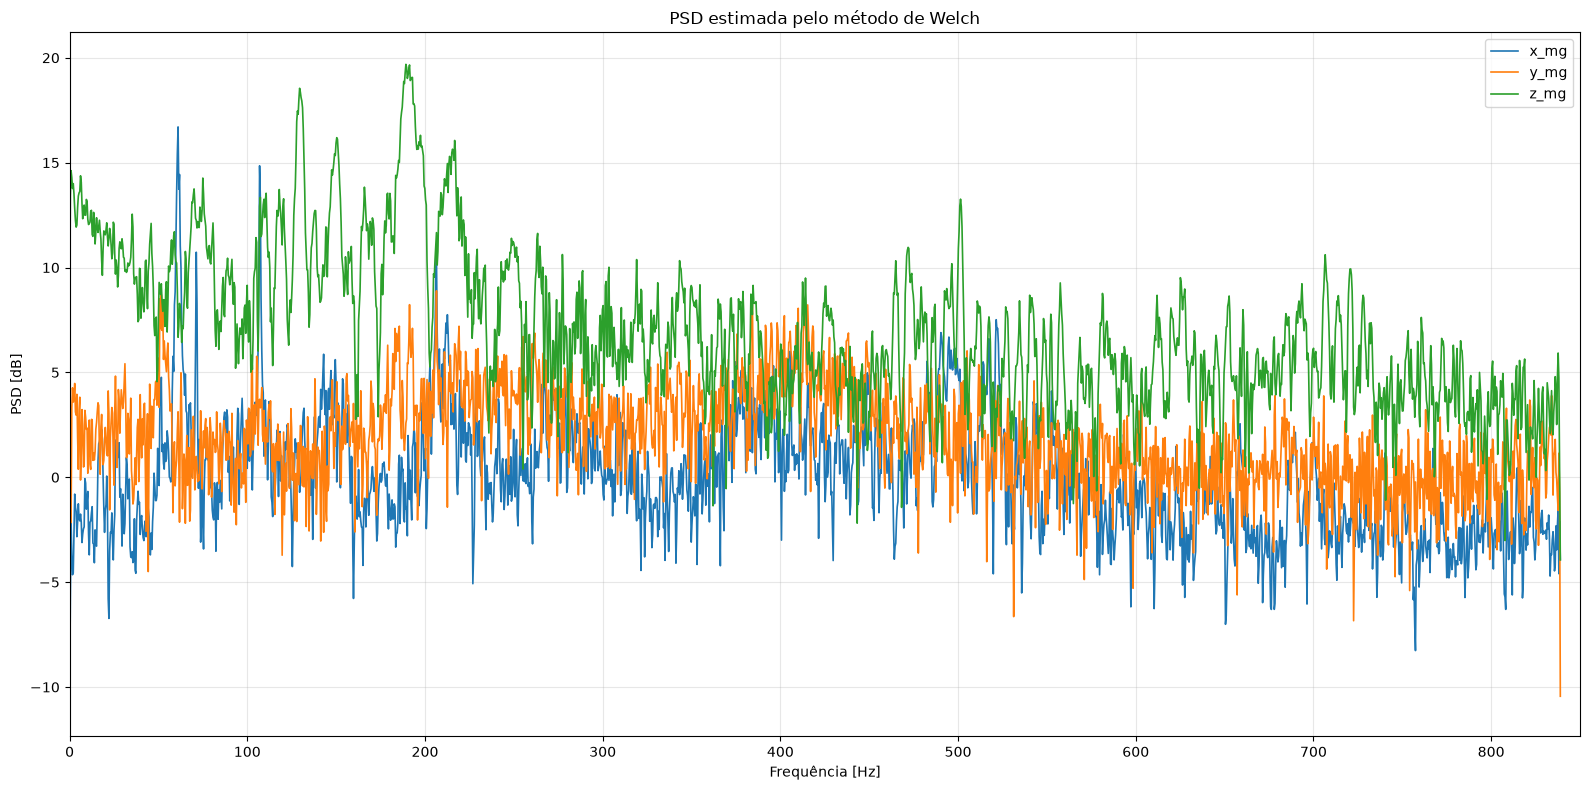

In [26]:
fig_welch, ax_welch = plt.subplots(figsize=(16, 8))

for eixo in EIXOS:
    frequencias, psd = calcular_psd_welch(df[eixo], FS_ESTIMADA)

    ax_welch.plot(
        frequencias,
        10 * np.log10(psd + 1e-20),
        linewidth=1.2,
        label=eixo
    )

ax_welch.set_title("PSD estimada pelo método de Welch")
ax_welch.set_xlabel("Frequência [Hz]")
ax_welch.set_ylabel("PSD [dB]")
ax_welch.set_xlim(0, 850)
ax_welch.grid(True, alpha=0.30)
ax_welch.legend(loc="best")
fig_welch.tight_layout()
plt.show()

| Saída                                           | Conteúdo                           

| 150rpm_aj_17115_Base.csv                        | Dataset reconstruído, sem linhas com outlier em qualquer eixo e com x_zscore, y_zscore e z_zscore   |

| tabelas/01_metricas_qualidade_apos_descarte.csv | Ausências, média, média móvel global, mediana, RMS, curtose, assimetria, IQR, dispersão e amplitude |

| tabelas/02_exclusoes_outliers_por_eixo.csv      | Limites IQR, valores abaixo/acima e total excluído por eixo                                         |

| tabelas/03_resumo_exclusao_global.csv           | Número de linhas removidas na exclusão conjunta dos eixos                                           |

| graficos/                                       | Barras por bloco, série média, sinais XYZ, outliers e FFT                                           |

| data_card_snapshot/                             | Resumo estatístico e histogramas reproduzidos localmente a partir do CSV                            |

| off_machine_1_analise.zip                       | Pacote único para download no painel de saída do Kaggle                                             |


O Data Card mostra aproximadamente 23,5 mil amostras por coluna antes do descarte, então a exclusão das 2.000 leituras transitórias ainda preservará uma série extensa para análise estatística, espectral e preparação de modelos.


In [27]:
#Análise de picos

from scipy.signal import find_peaks

def encontrar_picos_psd(sinal, fs, nperseg=4096):
    frequencias, psd = welch(
        sinal.interpolate(limit_direction="both").to_numpy(),
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="linear",
        scaling="density"
    )

    psd_db = 10 * np.log10(psd + 1e-20)

    distancia_minima_bins = max(1, int(5 / (fs / nperseg)))

    indices, propriedades = find_peaks(
        psd_db,
        prominence=1.0,
        distance=distancia_minima_bins
    )

    tabela = pd.DataFrame({
        "frequencia_hz": frequencias[indices],
        "psd_db": psd_db[indices],
        "prominencia_db": propriedades["prominences"]
    })

    return tabela.sort_values("psd_db", ascending=False), frequencias, psd_db

EIXOS = ["x_mg", "y_mg", "z_mg"]

tabelas_picos = {}

for eixo in EIXOS:
    tabela_picos, _, _ = encontrar_picos_psd(
        #[EIXOS],
        df[eixo],
        FS_ESTIMADA,
        nperseg=4096
    )

    tabelas_picos[eixo] = tabela_picos.head(20)

    print(f"\nPrincipais picos — {eixo}")
    display(tabelas_picos[eixo])


Principais picos — x_mg


,frequencia_hz,psd_db,prominencia_db
8,61.035156,16.703085,24.964934
14,106.913931,14.849269,18.373821
9,71.275954,10.728609,10.715522
28,206.454488,10.599193,16.375848
29,212.598967,7.751328,5.115871
73,521.461436,7.513046,12.586546
69,490.329410,6.897472,11.499428
70,498.112416,6.156742,1.043453
58,405.535602,6.005790,9.975540
19,142.961540,5.866960,10.123279



Principais picos — y_mg


,frequencia_hz,psd_db,prominencia_db
28,206.454488,8.887703,13.654432
7,51.613622,8.703372,12.418191
53,384.234742,8.504155,9.929974
26,191.298107,8.228564,10.264420
58,415.366768,8.217004,7.651805
57,410.041553,8.055102,6.833116
56,402.258547,7.704757,4.339450
55,394.885172,7.357818,4.574772
25,185.563260,7.205127,5.927624
30,219.153078,7.201633,8.376939



Principais picos — z_mg


,frequencia_hz,psd_db,prominencia_db
24,189.249948,19.687400,16.921421
18,129.443687,18.546366,13.988195
21,150.334915,16.191563,9.036726
25,216.695286,16.059787,10.797511
0,0.819264,14.618113,7.603825
1,6.144479,14.374149,2.447676
10,74.962642,14.266127,9.253443
23,165.900928,13.831461,10.946490
9,70.047059,13.748676,1.863695
17,117.973993,13.719776,7.420555


A proeminência representa a diferença vertical entre o pico e a linha de base ao redor dele; por isso, é mais significativa que simplesmente selecionar os maiores valores de amplitude.

Usemos esta função para reduzir a quantidade de falsos picos:

In [28]:
from scipy.signal import welch, find_peaks

def encontrar_picos_psd_robustos(
    sinal,
    fs,
    nperseg=4096,
    faixa_hz=(1, 850),
    proeminencia_db=3.0,
    distancia_minima_hz=10.0,
    suavizacao_bins=5
):
    vetor = (
        sinal
        .interpolate(limit_direction="both")
        .to_numpy(dtype=np.float64)
    )

    frequencias, psd = welch(
        vetor,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="linear",
        scaling="density"
    )

    psd_db = 10 * np.log10(psd + 1e-20)

    # Suavização somente para localizar picos,
    # sem alterar a PSD original exportada.
    psd_suave = (
        pd.Series(psd_db)
        .rolling(
            window=suavizacao_bins,
            center=True,
            min_periods=1
        )
        .median()
        .to_numpy()
    )

    mascara_faixa = (
        (frequencias >= faixa_hz[0]) &
        (frequencias <= faixa_hz[1])
    )

    frequencias_faixa = frequencias[mascara_faixa]
    psd_faixa = psd_suave[mascara_faixa]

    resolucao_hz = fs / nperseg
    distancia_bins = max(
        1,
        int(np.ceil(distancia_minima_hz / resolucao_hz))
    )

    indices, propriedades = find_peaks(
        psd_faixa,
        prominence=proeminencia_db,
        distance=distancia_bins
    )

    tabela = pd.DataFrame({
        "frequencia_hz": frequencias_faixa[indices],
        "psd_db_suavizada": psd_faixa[indices],
        "prominencia_db": propriedades["prominences"]
    })

    tabela = tabela.sort_values(
        by=["prominencia_db", "psd_db_suavizada"],
        ascending=False
    ).reset_index(drop=True)

    return tabela, frequencias, psd_db, psd_suave

In [29]:
# Para os três eixos:
tabelas_picos_robustos = {}

for eixo in EIXOS:
    tabela, frequencias, psd_db, psd_suave = \
        encontrar_picos_psd_robustos(
            df[eixo],
            FS_ESTIMADA,
            nperseg=4096,
            faixa_hz=(1, 850),
            proeminencia_db=3.0,
            distancia_minima_hz=10.0,
            suavizacao_bins=5
        )

    tabelas_picos_robustos[eixo] = tabela

    tabela.to_csv(
        PASTA_TABELAS / f"picos_psd_robustos_{eixo}.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(f"\nPicos robustos — {eixo}")
    display(tabela.head(15))


Picos robustos — x_mg


,frequencia_hz,psd_db_suavizada,prominencia_db
0,61.035156,14.435085,18.986115
1,106.913931,9.510671,11.757957
2,521.871068,7.049678,10.367319
3,206.454488,6.924826,10.070286
4,490.739042,6.283647,7.265519
5,373.993944,4.393214,6.677240
6,689.410523,1.616103,6.557527
7,149.515651,4.543401,6.516642
8,266.670381,4.288493,6.388090
9,17.614173,1.905413,5.972815



Picos robustos — y_mg


,frequencia_hz,psd_db_suavizada,prominencia_db
0,413.728240,7.263918,8.761796
1,51.613622,7.948574,8.297212
2,184.743996,6.857893,6.451581
3,602.568556,3.164303,4.917675
4,260.935534,6.373367,4.808623
5,547.268247,3.269957,4.797964
6,682.856413,2.660305,4.469437
7,448.546954,5.814440,4.426617
8,342.452286,5.311309,4.381611
9,106.094668,3.719257,4.371153



Picos robustos — z_mg


,frequencia_hz,psd_db_suavizada,prominencia_db
0,190.069211,19.461912,15.345832
1,129.853319,18.104118,12.297991
2,501.389471,12.917033,11.627613
3,215.876022,15.571096,9.652055
4,706.615064,9.911857,8.982533
5,471.895973,10.833595,8.657105
6,263.802957,11.014631,7.569144
7,625.507944,8.714978,7.446784
8,150.334915,15.929608,7.374924
9,165.900928,12.772362,7.175556


Para verificar se realmente existe concentração de energia, listemos os maiores valores da PSD:

In [30]:
def maiores_componentes_psd(sinal, fs, nperseg=4096, quantidade=15):
    vetor = (
        sinal
        .interpolate(limit_direction="both")
        .to_numpy(dtype=np.float64)
    )

    frequencias, psd = welch(
        vetor,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="linear",
        scaling="density"
    )

    psd_db = 10 * np.log10(psd + 1e-20)

    tabela = pd.DataFrame({
        "frequencia_hz": frequencias,
        "psd_db": psd_db,
        "psd_linear": psd
    })

    return tabela.sort_values(
        "psd_db",
        ascending=False
    ).head(quantidade)


for eixo in EIXOS:
    print(f"\nMaiores componentes espectrais — {eixo}")
    display(maiores_componentes_psd(df[eixo], FS_ESTIMADA))


Maiores componentes espectrais — x_mg


,frequencia_hz,psd_db,psd_linear
149,61.035156,16.703085,46.806751
148,60.625524,15.423693,34.863364
261,106.913931,14.849269,30.544073
151,61.854420,14.435085,27.765694
150,61.444788,13.733506,23.623843
147,60.215892,13.501817,22.396579
262,107.323563,13.381847,21.786359
146,59.806260,11.276689,13.417415
152,62.264052,11.042075,12.711812
174,71.275954,10.728609,11.826626



Maiores componentes espectrais — y_mg


,frequencia_hz,psd_db,psd_linear
504,206.454488,8.887703,7.740523
126,51.613622,8.703372,7.418861
124,50.794358,8.515019,7.103983
938,384.234742,8.504155,7.086234
467,191.298107,8.228564,6.650532
1014,415.366768,8.217004,6.632853
1001,410.041553,8.055102,6.390137
937,383.825110,7.991499,6.297235
128,52.432886,7.948574,6.235300
1011,414.137872,7.827912,6.064447



Maiores componentes espectrais — z_mg


,frequencia_hz,psd_db,psd_linear
462,189.249948,19.687400,93.055068
467,191.298107,19.658390,92.435543
463,189.659579,19.532712,89.798936
466,190.888475,19.461912,88.346880
461,188.840316,19.292212,84.961319
465,190.478843,19.175778,82.713771
471,192.936635,19.064791,80.626732
470,192.527003,19.059169,80.522435
464,190.069211,19.016225,79.730138
469,192.117371,18.980008,79.068008


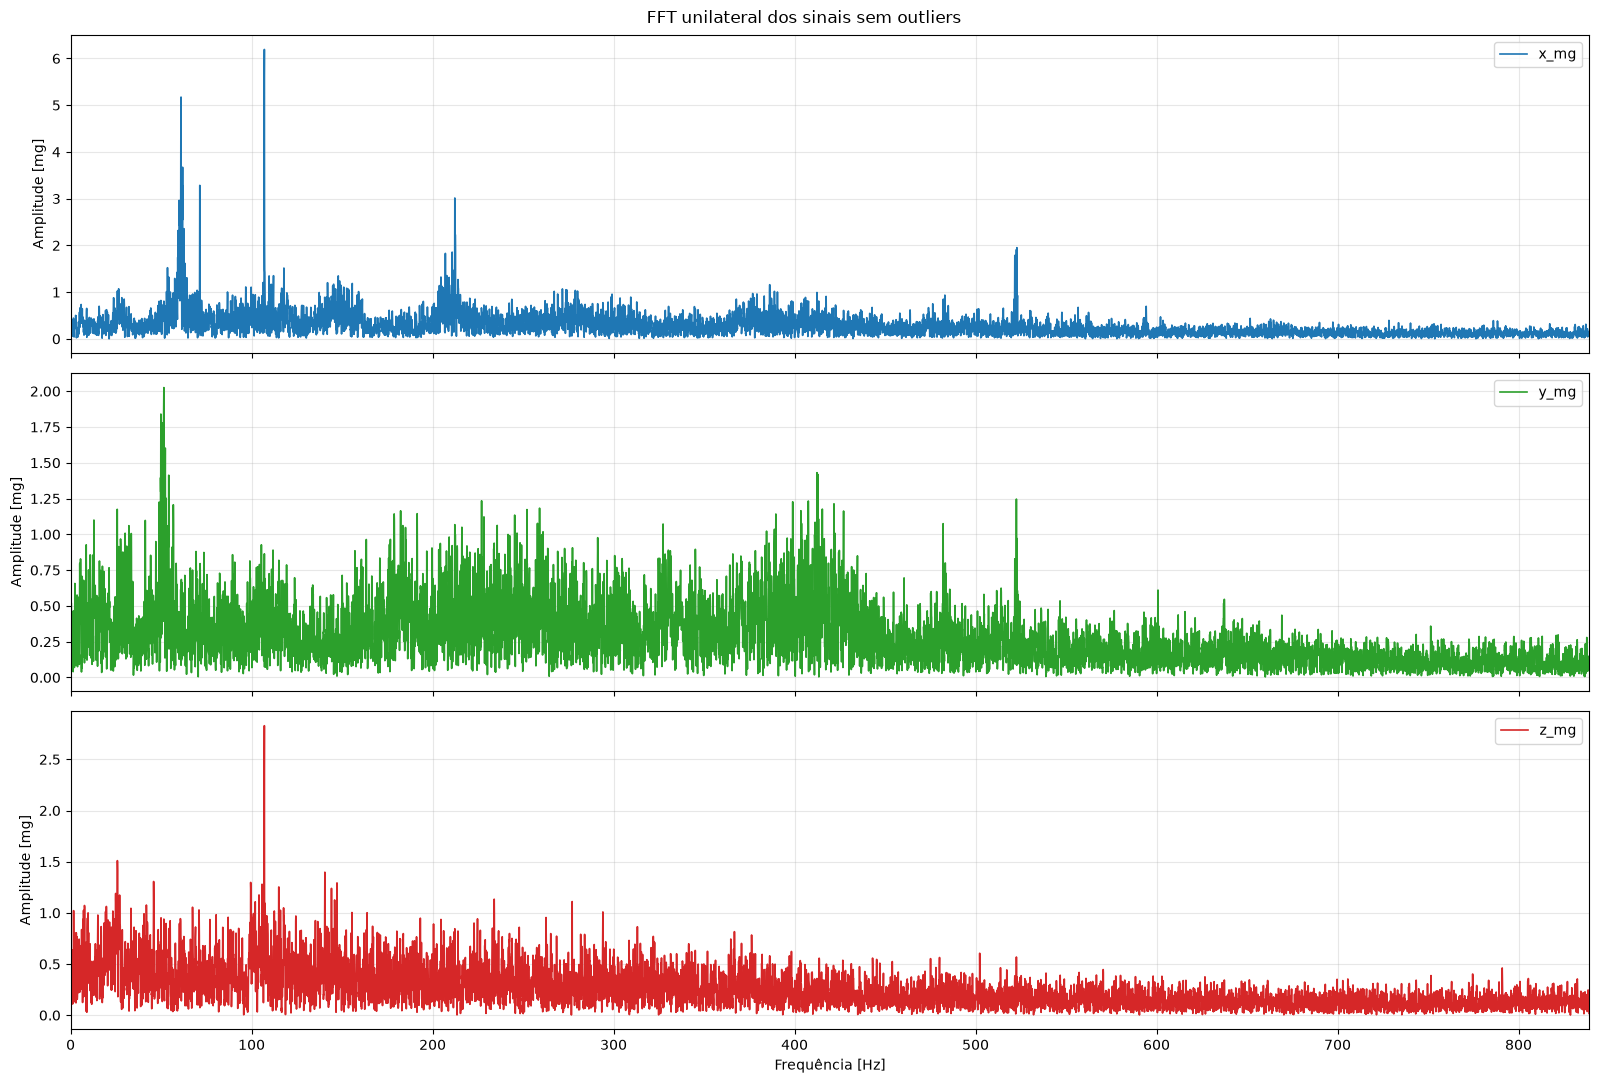

In [31]:
# ------------------------------------------------------------
# FFT DOS SINAIS X, Y E Z SEM OUTLIERS
# ------------------------------------------------------------

# Substitui os outliers por NaN e interpola os valores,
# preservando o eixo temporal original.
df_fft_limpo = df.copy()

for eixo in EIXOS:
    mascara = mascaras_outliers[f"{eixo}_outlier"]

    df_fft_limpo.loc[mascara, eixo] = np.nan

    df_fft_limpo[eixo] = (
        df_fft_limpo[eixo]
        .interpolate(limit_direction="both")
    )

# Grade temporal uniforme para a FFT.
tempo_uniforme = np.arange(
    df_fft_limpo[COLUNA_TEMPO].iloc[0],
    df_fft_limpo[COLUNA_TEMPO].iloc[-1],
    1_000_000 / FS_ESTIMADA
)

df_fft_limpo_uniforme = pd.DataFrame({
    COLUNA_TEMPO: tempo_uniforme
})

for eixo in EIXOS:
    df_fft_limpo_uniforme[eixo] = np.interp(
        tempo_uniforme,
        df_fft_limpo[COLUNA_TEMPO],
        df_fft_limpo[eixo]
    )

fig_fft_limpa, axes_fft_limpa = plt.subplots(
    3, 1, figsize=(16, 11), sharex=True
)

for linha, eixo in enumerate(EIXOS):
    frequencias, amplitude = calcular_fft_unilateral(
        df_fft_limpo_uniforme[eixo],
        FS_ESTIMADA
    )

    axes_fft_limpa[linha].plot(
        frequencias,
        amplitude,
        color=cores[eixo],
        linewidth=1.2,
        label=eixo
    )
    axes_fft_limpa[linha].set_ylabel("Amplitude [mg]")
    axes_fft_limpa[linha].set_xlim(0, NYQUIST)
    axes_fft_limpa[linha].grid(True, alpha=0.30)
    axes_fft_limpa[linha].legend(loc="best")

axes_fft_limpa[-1].set_xlabel("Frequência [Hz]")
fig_fft_limpa.suptitle("FFT unilateral dos sinais sem outliers")
fig_fft_limpa.tight_layout()
plt.show()

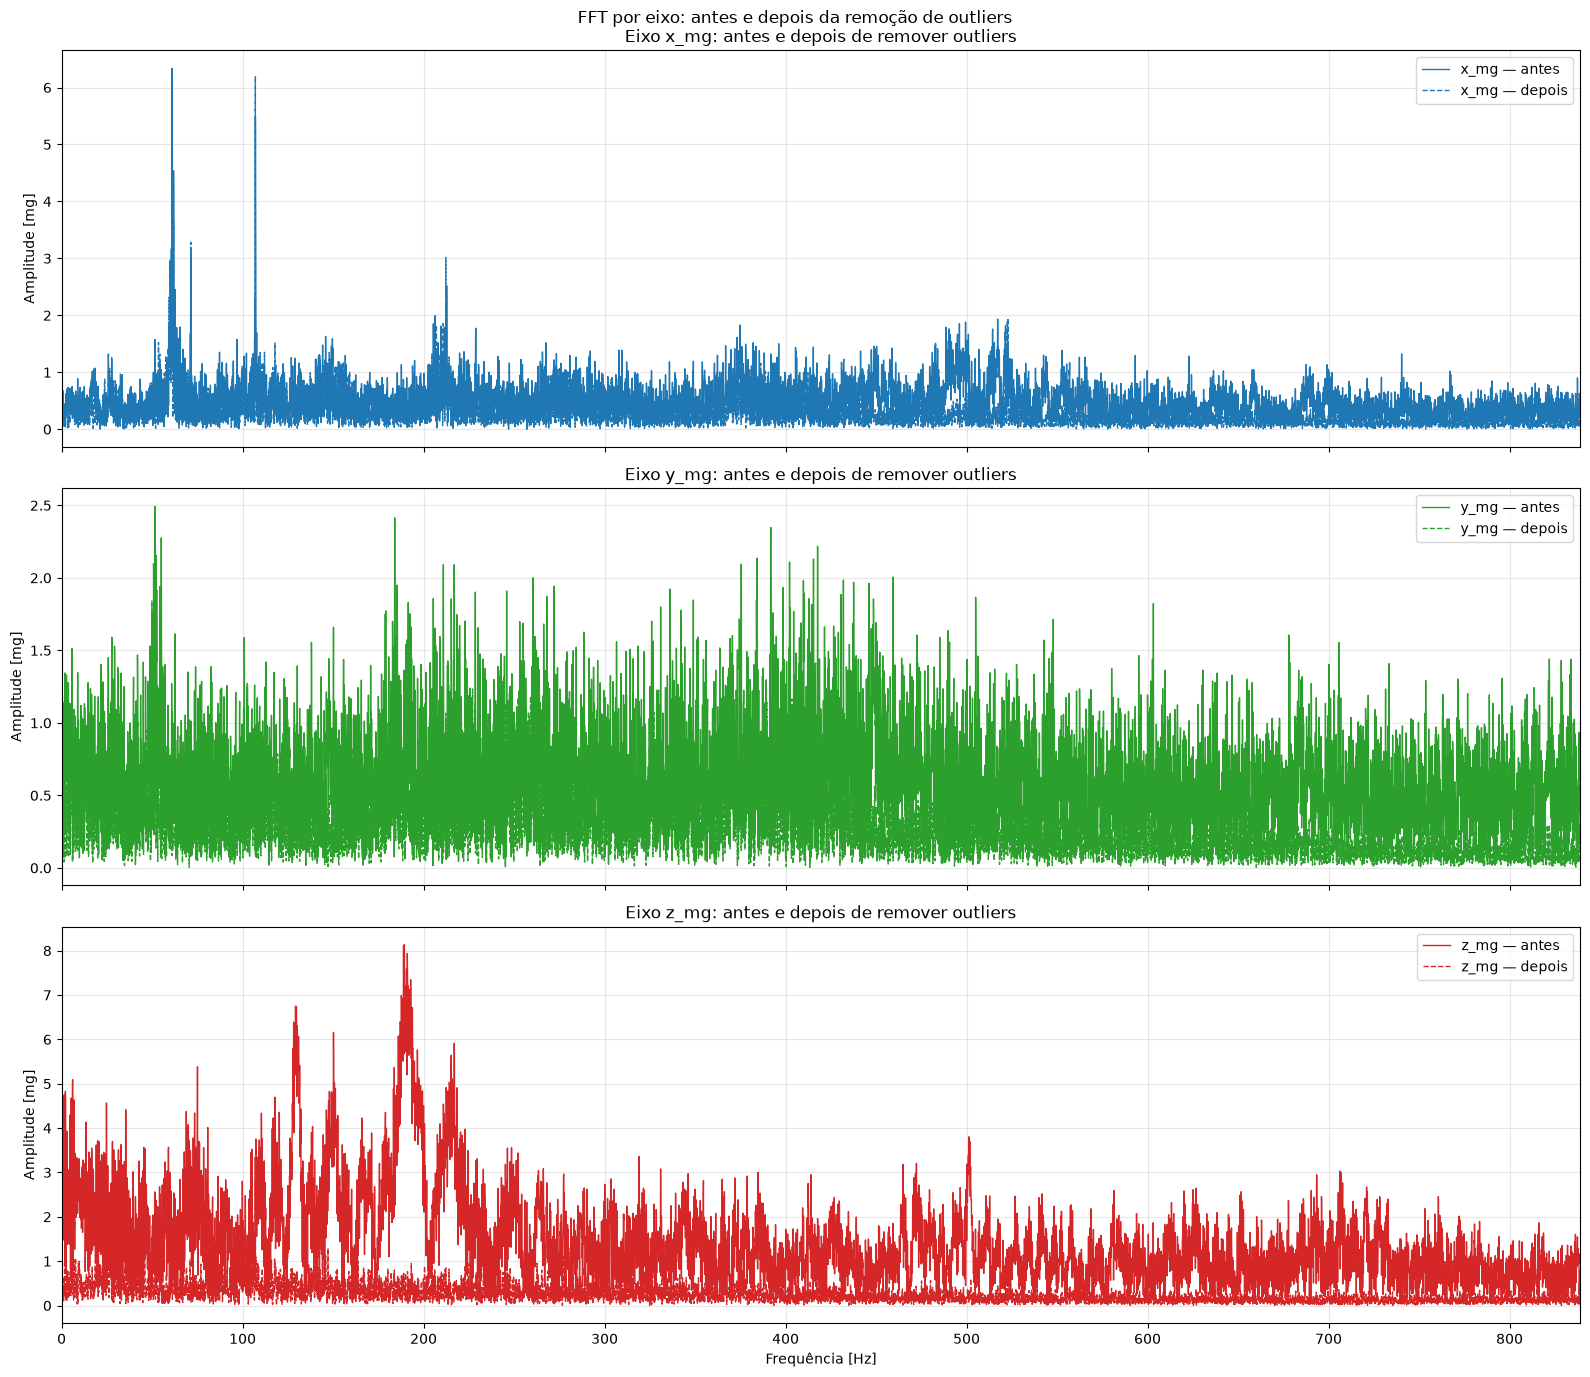

In [32]:
# ------------------------------------------------------------
# FFT POR EIXO: ANTES E DEPOIS DA REMOÇÃO DE OUTLIERS
# ------------------------------------------------------------

# Reutiliza o sinal já limpo (interpolação nos outliers)
# e a grade uniforme gerada na célula anterior.
# Caso ainda não existam, rode antes a célula que cria:
#   df_fft_limpo, tempo_uniforme, df_fft_limpo_uniforme

fig_fft_antes_depois, axes_antes_depois = plt.subplots(
    3, 1, figsize=(16, 14), sharex=True
)

for linha, eixo in enumerate(EIXOS):
    # Sinal bruto (antes) — usa o Series original e a mesma função FFT.
    frequencias_brutas, amplitude_bruta = calcular_fft_unilateral(
        df[eixo],
        FS_ESTIMADA
    )

    # Sinal limpo (depois) — usa a grade temporal uniforme interpolada.
    frequencias_limpo, amplitude_limpo = calcular_fft_unilateral(
        df_fft_limpo_uniforme[eixo],
        FS_ESTIMADA
    )

    ax = axes_antes_depois[linha]
    ax.plot(
        frequencias_brutas,
        amplitude_bruta,
        color=cores[eixo],
        linewidth=1.0,
        label=f"{eixo} — antes"
    )
    ax.plot(
        frequencias_limpo,
        amplitude_limpo,
        color=cores[eixo],
        linewidth=1.0,
        linestyle="--",
        label=f"{eixo} — depois"
    )

    ax.set_title(f"Eixo {eixo}: antes e depois de remover outliers")
    ax.set_ylabel("Amplitude [mg]")
    ax.set_xlim(0, NYQUIST)
    ax.grid(True, alpha=0.30)
    ax.legend(loc="best")

axes_antes_depois[-1].set_xlabel("Frequência [Hz]")
fig_fft_antes_depois.suptitle(
    "FFT por eixo: antes e depois da remoção de outliers"
)
fig_fft_antes_depois.tight_layout()
plt.show()

#### Código Python para Filtragem e Plotação Zoom na Faixas de Baixa Frequência:

In [33]:
import plotly.graph_objects as go
from scipy.signal import butter, filtfilt

# -----------------------------------------------------------------------------
# 1. PARÂMETROS DO FILTRO E DA FREQUÊNCIA DE INTERESSE (150 RPM = 2.5 Hz)
# -----------------------------------------------------------------------------
FS = FS_ESTIMADA          # Frequência de amostragem estimada (Hz)
FREQ_ROTACAO_HZ = 2.5     # 150 RPM / 60
FC_LOWPASS = 20.0         # Frequência de corte do passa-baixa (Hz)
FC_HIGHPASS = 0.5         # Frequência de corte para remover DC (0 Hz)

def aplicar_filtro_passa_banda(sinal, fs, f_low=0.5, f_high=20.0, ordem=4):
    """Aplica um filtro Butterworth Passa-Banda (Zero-Phase) no sinal de aceleração."""
    nyquist = 0.5 * fs
    low = f_low / nyquist
    high = f_high / nyquist
    b, a = butter(ordem, [low, high], btype='band')
    return filtfilt(b, a, sinal)


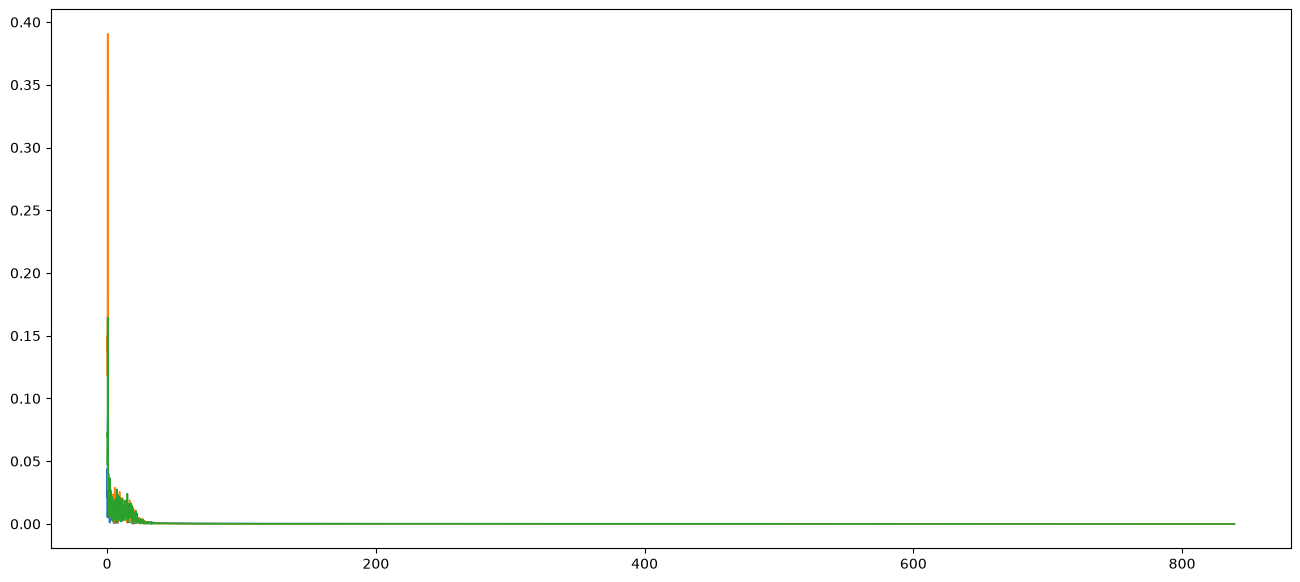

In [34]:
# -----------------------------------------------------------------------------
# 2. PROCESSAMENTO DOS EIXOS E CÁLCULO DA FFT
# -----------------------------------------------------------------------------
fig_zoom, ax_zoom = plt.subplots(figsize=(16, 7))

for eixo in EIXOS:
    # Trata o nome da coluna: extrai a letra do eixo ('x', 'y' ou 'z') para buscar 'x_zscore'
    letra_eixo = eixo.split('_')[0]
    coluna_zscore = f"{letra_eixo}_zscore"

    # Fallback de segurança: busca a coluna zscore ou a coluna original do eixo caso zscore não exista
    if coluna_zscore in df_off_machine_1_N.columns:
        sinal_original = df_off_machine_1_N[coluna_zscore].values
    elif eixo in df_off_machine_1_N.columns:
        sinal_original = df_off_machine_1_N[eixo].values
    else:
        raise KeyError(f"Coluna {coluna_zscore} ou {eixo} não foi encontrada no DataFrame.")

    # Aplica a filtragem passa-banda (Butterworth Zero-Phase)
    sinal_filtrado = aplicar_filtro_passa_banda(
        sinal_original,
        fs=FS,
        f_low=FC_HIGHPASS,
        f_high=FC_LOWPASS
    )

    # Cálculo da FFT do sinal filtrado
    N = len(sinal_filtrado)
    fft_vals = np.fft.rfft(sinal_filtrado)
    fft_freqs = np.fft.rfftfreq(N, d=1 / FS)
    magnitude = np.abs(fft_vals) * (2.0 / N)  # Normalização de amplitude

    ax_zoom.plot(
        fft_freqs,
        magnitude,
        linewidth=1.2,
        label=f"Eixo {letra_eixo.upper()} (Filtrado)"
    )




In [ ]:
# -----------------------------------------------------------------------------
# MARCADORES DE FREQUÊNCIA CARACTERÍSTICA DE ROTAÇÃO (1X, 2X e 3X)
# -----------------------------------------------------------------------------

# O gráfico Matplotlib criado na célula anterior deve existir:
# fig_zoom, ax_zoom = plt.subplots(...)

marcadores_rotacao = [
    (1, "#d62728", "1X (2.5 Hz)", "--"),
    (2, "#ff7f0e", "2X (5.0 Hz)", ":"),
    (3, "#2ca02c", "3X (7.5 Hz)", ":"),
]

for multiplicador, cor, rotulo, estilo_linha in marcadores_rotacao:
    frequencia_marcada = multiplicador * FREQ_ROTACAO_HZ

    # Equivalente Matplotlib de fig_zoom.add_vline(...)
    ax_zoom.axvline(
        x=frequencia_marcada,
        color=cor,
        linestyle=estilo_linha,
        linewidth=1.2
    )

    # Equivalente Matplotlib das anotações do Plotly.
    # A transformação mantém y como fração da altura visível do eixo.
    ax_zoom.text(
        frequencia_marcada,
        0.98,
        rotulo,
        color=cor,
        rotation=90,
        ha="right",
        va="top",
        fontsize=10,
        transform=ax_zoom.get_xaxis_transform()
    )

ax_zoom.grid(True, alpha=0.30)

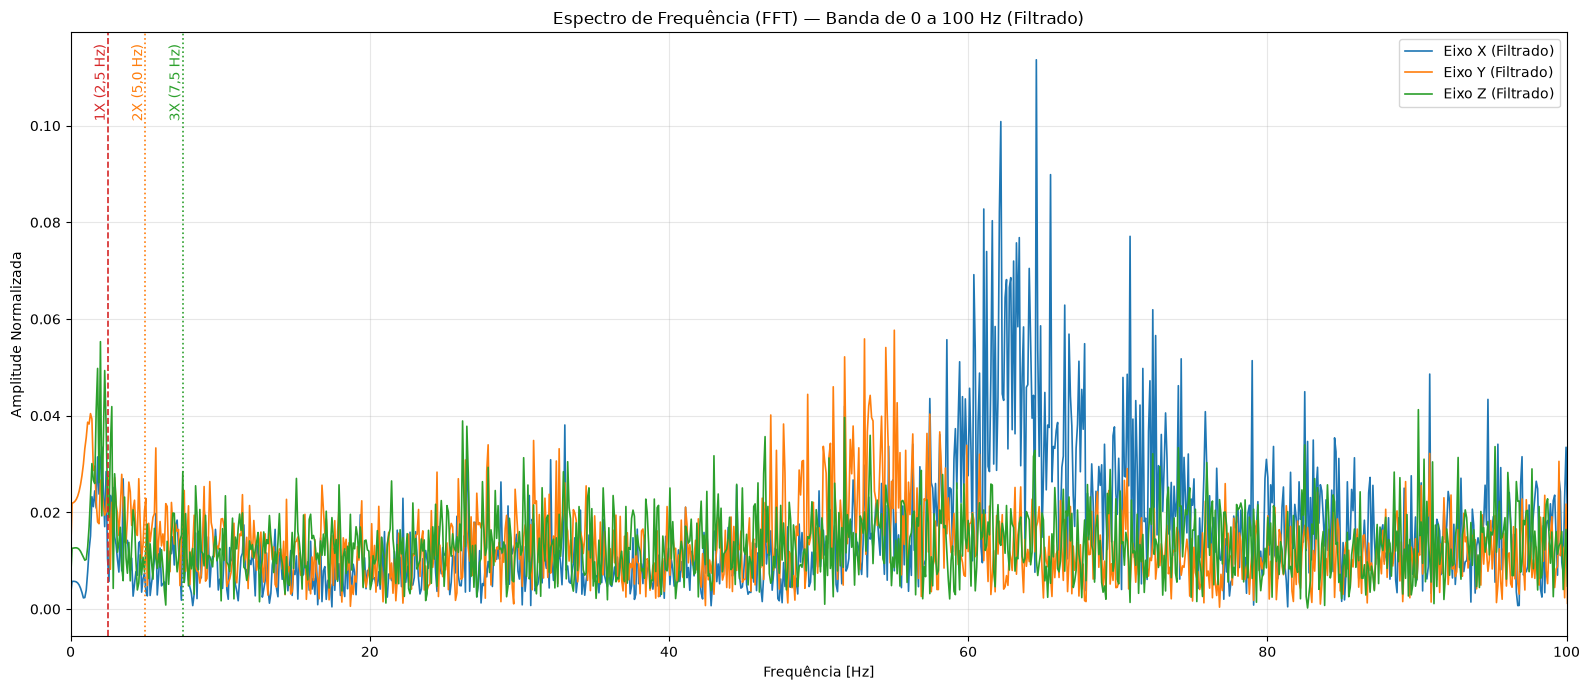

In [41]:
# -----------------------------------------------------------------------------
# MARCADORES DE FREQUÊNCIA CARACTERÍSTICA DE ROTAÇÃO (1X, 2X e 3X)
# -----------------------------------------------------------------------------

# 1X: Frequência fundamental de rotação do motoredutor (2.5 Hz)
# -----------------------------------------------------------------------------
# FFT FILTRADA E MARCADORES DE FREQUÊNCIA CARACTERÍSTICA
# Faixa de interesse: 0 a 100 Hz
# -----------------------------------------------------------------------------

# Mantém os parâmetros já usados no seu notebook.
FS = FS_ESTIMADA
FREQ_ROTACAO_HZ = 2.5
FC_LOWPASS = 140.0
FC_HIGHPASS = 1.5

def aplicar_filtro_passa_banda(
    sinal,
    fs,
    f_low=1.5,
    f_high=100.0,
    ordem=4
):
    nyquist = 0.5 * fs

    low = f_low / nyquist
    high = f_high / nyquist

    b, a = butter(
        ordem,
        [low, high],
        btype="band"
    )

    return filtfilt(b, a, sinal)


# Cria uma nova figura Matplotlib.
fig_zoom, ax_zoom = plt.subplots(
    figsize=(16, 7)
)


# -----------------------------------------------------------------------------
# PROCESSAMENTO DOS EIXOS E CÁLCULO DA FFT
# -----------------------------------------------------------------------------

for eixo in EIXOS:
    letra_eixo = eixo.split("_")[0]
    coluna_zscore = f"{letra_eixo}_zscore"

    # Mantém o fallback do seu código original.
    if coluna_zscore in df_off_machine_1_N.columns:
        sinal_original = df_off_machine_1_N[coluna_zscore].to_numpy()
    elif eixo in df_off_machine_1_N.columns:
        sinal_original = df_off_machine_1_N[eixo].to_numpy()
    else:
        raise KeyError(
            f"Coluna '{coluna_zscore}' ou '{eixo}' "
            "não foi encontrada no DataFrame."
        )

    # Aplica o mesmo conceito de filtragem passa-banda.
    sinal_filtrado = aplicar_filtro_passa_banda(
        sinal_original,
        fs=FS,
        f_low=FC_HIGHPASS,
        f_high=FC_LOWPASS
    )

    # FFT unilateral do sinal filtrado.
    N = len(sinal_filtrado)

    fft_vals = np.fft.rfft(sinal_filtrado)
    fft_freqs = np.fft.rfftfreq(
        N,
        d=1.0 / FS
    )

    magnitude = np.abs(fft_vals) * (2.0 / N)

    # Ajuste para DC e Nyquist, mantendo a normalização unilateral.
    magnitude[0] *= 0.5

    if N % 2 == 0:
        magnitude[-1] *= 0.5

    # Curva espectral de cada eixo.
    ax_zoom.plot(
        fft_freqs,
        magnitude,
        linewidth=1.2,
        label=f"Eixo {letra_eixo.upper()} (Filtrado)"
    )


# -----------------------------------------------------------------------------
# MARCADORES DE 1X, 2X E 3X
# -----------------------------------------------------------------------------

marcadores_rotacao = [
    (1, "#d62728", "1X (2,5 Hz)", "--"),
    (2, "#ff7f0e", "2X (5,0 Hz)", ":"),
    (3, "#2ca02c", "3X (7,5 Hz)", ":"),
]

for multiplicador, cor, rotulo, estilo_linha in marcadores_rotacao:
    frequencia_marcada = multiplicador * FREQ_ROTACAO_HZ

    ax_zoom.axvline(
        x=frequencia_marcada,
        color=cor,
        linestyle=estilo_linha,
        linewidth=1.2
    )

    ax_zoom.text(
        frequencia_marcada,
        0.98,
        rotulo,
        color=cor,
        fontsize=10,
        rotation=90,
        ha="right",
        va="top",
        transform=ax_zoom.get_xaxis_transform()
    )


# -----------------------------------------------------------------------------
# FORMATAÇÃO E EXIBIÇÃO
# -----------------------------------------------------------------------------

ax_zoom.set_title(
    "Espectro de Frequência (FFT) — Banda de 0 a 100 Hz (Filtrado)"
)

ax_zoom.set_xlabel("Frequência [Hz]")
ax_zoom.set_ylabel("Amplitude Normalizada")

ax_zoom.set_xlim(0, 100)

ax_zoom.grid(
    True,
    alpha=0.30
)

ax_zoom.legend(
    loc="best"
)

fig_zoom.tight_layout()

plt.show()

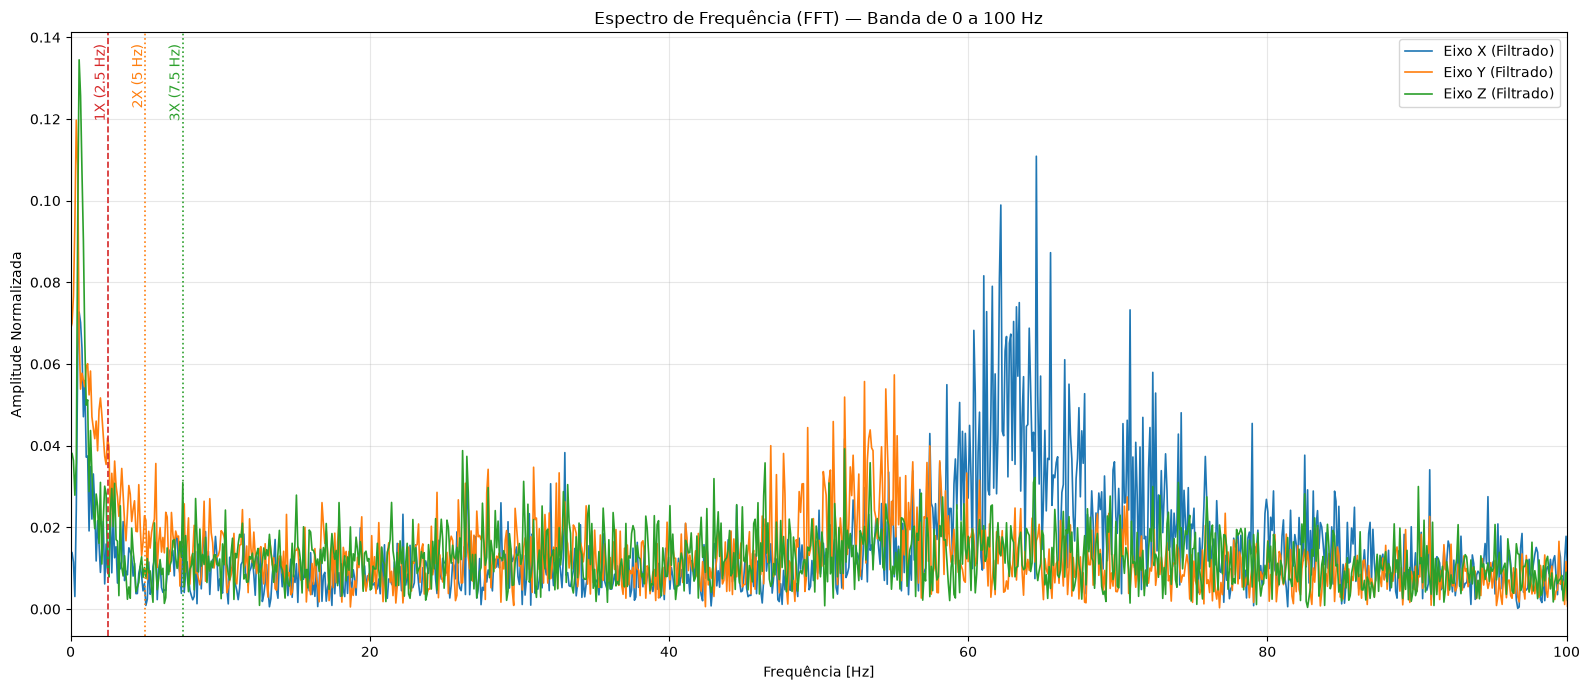

In [36]:

# -----------------------------------------------------------------------------
# 1. PARÂMETROS E FUNÇÃO DE FILTRAGEM
# -----------------------------------------------------------------------------
FS = FS_ESTIMADA          # Frequência de amostragem estimada (Hz)
FREQ_ROTACAO_HZ = 2.5     # 150 RPM / 60
FC_LOWPASS = 100.0        # Frequência de corte ajustada para 100 Hz
FC_HIGHPASS = 0.5         # Frequência de corte para remover offset DC (0 Hz)

def aplicar_filtro_passa_banda(sinal, fs, f_low=0.5, f_high=100.0, ordem=4):
    nyquist = 0.5 * fs
    low = f_low / nyquist
    high = f_high / nyquist
    b, a = butter(ordem, [low, high], btype='band')
    return filtfilt(b, a, sinal)

# -----------------------------------------------------------------------------
# 2. PROCESSAMENTO DOS EIXOS E CÁLCULO DA FFT
# -----------------------------------------------------------------------------
fig_zoom, ax_zoom = plt.subplots(figsize=(16, 7))

for eixo in EIXOS:
    letra_eixo = eixo.split('_')[0]
    coluna_zscore = f"{letra_eixo}_zscore"

    if coluna_zscore in df_off_machine_1_N.columns:
        sinal_original = df_off_machine_1_N[coluna_zscore].values
    elif eixo in df_off_machine_1_N.columns:
        sinal_original = df_off_machine_1_N[eixo].values
    else:
        raise KeyError(f"Coluna {coluna_zscore} ou {eixo} não foi encontrada no DataFrame.")

    sinal_filtrado = aplicar_filtro_passa_banda(
        sinal_original,
        fs=FS,
        f_low=FC_HIGHPASS,
        f_high=FC_LOWPASS
    )

    N = len(sinal_filtrado)
    fft_vals = np.fft.rfft(sinal_filtrado)
    fft_freqs = np.fft.rfftfreq(N, d=1 / FS)
    magnitude = np.abs(fft_vals) * (2.0 / N)

    ax_zoom.plot(
        fft_freqs,
        magnitude,
        linewidth=1.2,
        label=f"Eixo {letra_eixo.upper()} (Filtrado)"
    )

# -----------------------------------------------------------------------------
# 3. MARCAÇÕES DAS HARMÔNICAS DE ROTAÇÃO
# -----------------------------------------------------------------------------
for multiplicador, cor, rotulo in [
    (1, "#d62728", "1X (2.5 Hz)"),
    (2, "#ff7f0e", "2X (5 Hz)"),
    (3, "#2ca02c", "3X (7.5 Hz)")
]:
    frequencia = multiplicador * FREQ_ROTACAO_HZ
    ax_zoom.axvline(
        frequencia,
        linestyle=":" if multiplicador != 1 else "--",
        color=cor,
        linewidth=1.2
    )
    ax_zoom.text(
        frequencia,
        0.98,
        rotulo,
        color=cor,
        rotation=90,
        ha="right",
        va="top",
        transform=ax_zoom.get_xaxis_transform()
    )

# -----------------------------------------------------------------------------
# 4. CONFIGURAÇÃO DO ZOOM E LAYOUT (0 a 100 Hz)
# -----------------------------------------------------------------------------
ax_zoom.set_title("Espectro de Frequência (FFT) — Banda de 0 a 100 Hz")
ax_zoom.set_xlabel("Frequência [Hz]")
ax_zoom.set_ylabel("Amplitude Normalizada")
ax_zoom.set_xlim(0, 100)
ax_zoom.grid(True, alpha=0.30)
ax_zoom.legend(loc="best")
fig_zoom.tight_layout()
plt.show()


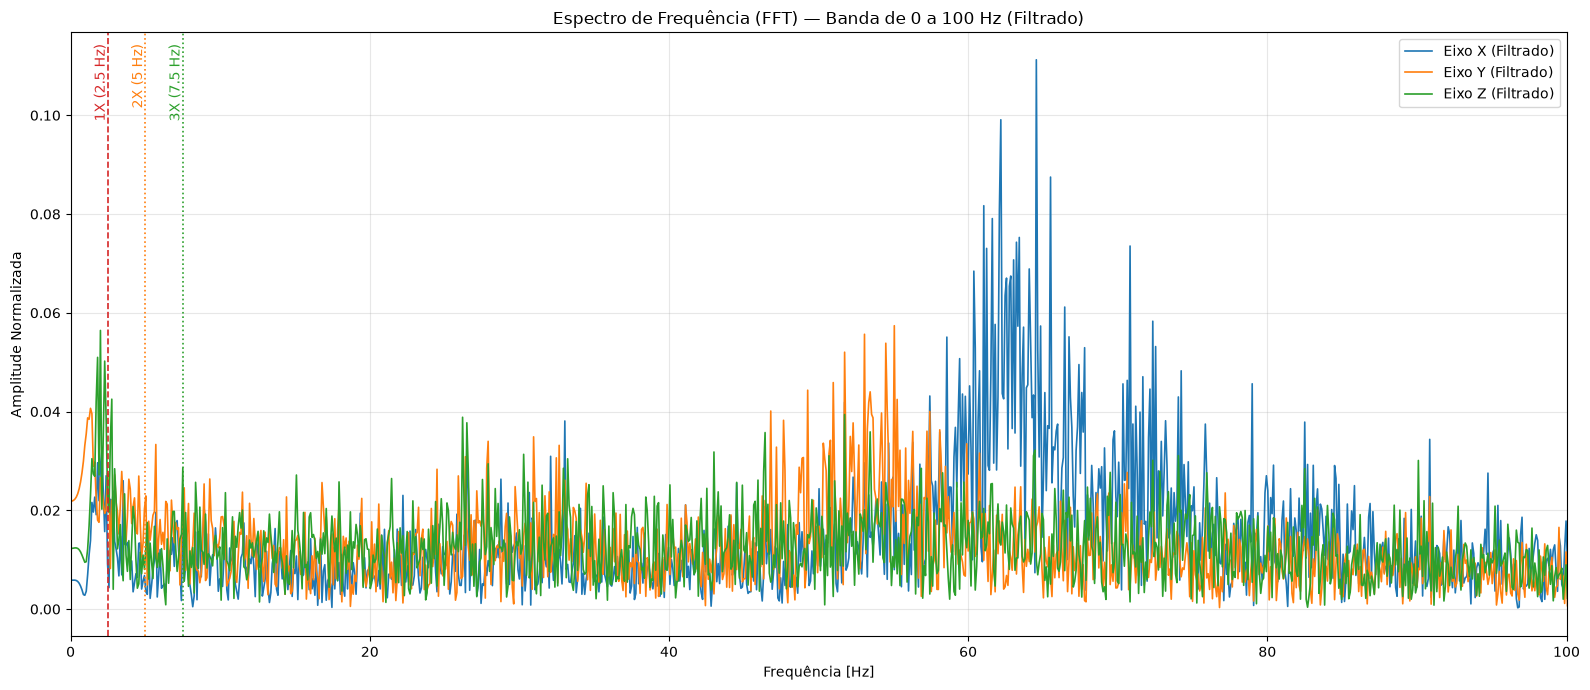

In [37]:
# -----------------------------------------------------------------------------
# 1. PARÂMETROS DE FILTRAGEM (Passa-altas ajustado para 1.5 Hz)
# -----------------------------------------------------------------------------
FS = FS_ESTIMADA
FREQ_ROTACAO_HZ = 2.5     # 150 RPM / 60
FC_LOWPASS = 100.0        # Frequência superior
FC_HIGHPASS = 1.5         # Elevei de 0.5 para 1.5 Hz para atenuar o pico de 0 Hz

def aplicar_filtro_passa_banda(sinal, fs, f_low=1.5, f_high=100.0, ordem=4):
    nyquist = 0.5 * fs
    low = f_low / nyquist
    high = f_high / nyquist
    b, a = butter(ordem, [low, high], btype='band')
    return filtfilt(b, a, sinal)

# -----------------------------------------------------------------------------
# 2. CÁLCULO DA FFT COM FILTRAGEM
# -----------------------------------------------------------------------------
fig_zoom, ax_zoom = plt.subplots(figsize=(16, 7))

for eixo in EIXOS:
    letra_eixo = eixo.split('_')[0]
    coluna_zscore = f"{letra_eixo}_zscore"

    if coluna_zscore in df_off_machine_1_N.columns:
        sinal_original = df_off_machine_1_N[coluna_zscore].values
    elif eixo in df_off_machine_1_N.columns:
        sinal_original = df_off_machine_1_N[eixo].values
    else:
        raise KeyError(f"Coluna {coluna_zscore} ou {eixo} não foi encontrada no DataFrame.")

    sinal_filtrado = aplicar_filtro_passa_banda(
        sinal_original,
        fs=FS,
        f_low=FC_HIGHPASS,
        f_high=FC_LOWPASS
    )

    N = len(sinal_filtrado)
    fft_vals = np.fft.rfft(sinal_filtrado)
    fft_freqs = np.fft.rfftfreq(N, d=1 / FS)
    magnitude = np.abs(fft_vals) * (2.0 / N)

    ax_zoom.plot(
        fft_freqs,
        magnitude,
        linewidth=1.2,
        label=f"Eixo {letra_eixo.upper()} (Filtrado)"
    )

# -----------------------------------------------------------------------------
# 3. HARMÔNICAS 1X, 2X E 3X
# -----------------------------------------------------------------------------
for multiplicador, cor, rotulo in [
    (1, "#d62728", "1X (2.5 Hz)"),
    (2, "#ff7f0e", "2X (5 Hz)"),
    (3, "#2ca02c", "3X (7.5 Hz)")
]:
    frequencia = multiplicador * FREQ_ROTACAO_HZ
    ax_zoom.axvline(
        frequencia,
        linestyle=":" if multiplicador != 1 else "--",
        color=cor,
        linewidth=1.2
    )
    ax_zoom.text(
        frequencia,
        0.98,
        rotulo,
        color=cor,
        rotation=90,
        ha="right",
        va="top",
        transform=ax_zoom.get_xaxis_transform()
    )

# -----------------------------------------------------------------------------
# 4. CONFIGURAÇÃO DE LAYOUT (0 a 100 Hz)
# -----------------------------------------------------------------------------
ax_zoom.set_title("Espectro de Frequência (FFT) — Banda de 0 a 100 Hz (Filtrado)")
ax_zoom.set_xlabel("Frequência [Hz]")
ax_zoom.set_ylabel("Amplitude Normalizada")
ax_zoom.set_xlim(0, 100)
ax_zoom.grid(True, alpha=0.30)
ax_zoom.legend(loc="best")
fig_zoom.tight_layout()
plt.show()


In [38]:

# -----------------------------------------------------------------------------
# 3. LAYOUT COM FOCO NA BANDA DE INTERESSE (0 a 15 Hz)
# -----------------------------------------------------------------------------
ax_zoom.set_title("Espectro de Frequência (FFT) - Banda de Baixa Frequência [0 - 15 Hz]")
ax_zoom.set_xlabel("Frequência [Hz]")
ax_zoom.set_ylabel("Amplitude Normalizada")
ax_zoom.set_xlim(0, 15)  # ZOOM focado na rotação
ax_zoom.grid(True, alpha=0.30)
ax_zoom.legend(loc="best")
fig_zoom.tight_layout()
plt.show()

- Antes: O gráfico exibia de $0$ a $850\text{ Hz}$. Existiam picos de grande amplitude em altas frequências ou um offset DC altíssimo que alterava a escala Y para $6\text{ mg}$ ou $8\text{ mg}$. Nessa escala vertical comprimida, a atividade entre $0$ e $100\text{ Hz}$ ficava estreitada, parecendo-se com uma linha reta no piso de ruído.

- Posterior: Ao segmentar o gráfico em $100\text{ Hz}$ e aplicar-se o filtro passa-baixa, o Plotly recalculou a escala do eixo Y para a amplitude máxima (aprox. $0{,}11$). Com esse zoom aplicado na amplitude, todas as variações e componentes espectrais dessa faixa inferior tornaram-se visíveis.

Há uma elevação e concentração de energia através de um pico dominante de magnitude próximo de $0{,}112$ entre $60\text{ Hz}$ e $68\text{ Hz}$, que se desdobra até $75\text{ Hz}$.

Meu comentário sobre o efeito Físico gerador no Motoredutor:

Frequência de Engrenamento (Gear Mesh Frequency - GMF): Em redutores de velocidade, a $GMF$ é dada por:

$$GMF = f_{\text{rot}} \times N_{\text{dentes}}$$

Se o eixo gira a $150\text{ RPM}$ ($2{,}5\text{ Hz}$), uma engrenagem com $24$ a $27$ dentes gerará um pico entre:

$60\text{ Hz}$ e $67{,}5\text{ Hz}$ -->  ($2{,}5 \times 25 = 62{,}5\text{ Hz}$).

Entendo como uma ressonância Estrutural pois a energia está agrupada no formato de uma "montanha" de amplitudes, com banda relativamente larga ao redor do Eixo X, e o acelerômetro está captando uma resposta da carcaça do motoredutor advinda das forças de engrenamento.

Comportamento em Baixa Frequência ($0 - 10\text{ Hz}$): Os picos nas linhas $1\text{X}$ ($2{,}5\text{ Hz}$) e $2\text{X}$ ($5\text{ Hz}$) existem, porém têm uma amplitude máxima em torno de $0{,}04$ a $0{,}05$. Dessa forma, a energia mecânica desse engrenamento/vibração, na faixa de $60 a 75\text{ Hz}$, é quase 3 vezes maior do que a outra força, provavelmente associada a um desbalanceamento ou excentricidade do eixo de entrada ($2{,}5\text{ Hz}$). Essas conclusões de "balanceamento" ou "excentricidade" advém do funcionamento da bancada quando dos testes.


